<div>
  <h1>Nama: DIO IRSAPUTRA SIREGAR</h1>
  <h1>NIM : 1301213012</h1>
</div>

# Import Package

In [6]:
#Import Package
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt
import yfinance as yf



# Mengumpulkan Dataset

##Dataset Saham

In [2]:
import yfinance as yf

# Daftar ticker saham
tickers = [
    'ACES.JK', 'ADRO.JK', 'AKRA.JK', "AMRT.JK", "ANTM.JK", "ARTO.JK", "ASII.JK",
    'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BMRI.JK', 'BRPT.JK', 'CPIN.JK', 'GOTO.JK',
    'ICBP.JK', 'INCO.JK', 'INDF.JK', 'INKP.JK', 'KLBF.JK', 'MAPI.JK', 'MBMA.JK',
    'MDKA.JK', 'MEDC.JK', 'PGAS.JK', 'PGEO.JK', 'PTBA.JK', 'SMGR.JK', 'TLKM.JK',
    'UNTR.JK', 'UNVR.JK',
]


# Mengunduh harga penutupan saham disesuaikan (Close)
data = yf.download(tickers, start='2014-11-04', end='2024-11-04', rounding=True, interval="1wk")['Close']
data



/tmp/ipython-input-4070602089.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2014-11-04', end='2024-11-04', rounding=True, interval="1wk")['Close']
[*********************100%***********************]  30 of 30 completed


Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ARTO.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,...,MBMA.JK,MDKA.JK,MEDC.JK,PGAS.JK,PGEO.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
Date,,,,,,,,,,,,,,,,,,,,,
2014-11-03,576.70,423.87,604.05,471.24,633.21,NaN,4178.91,2077.15,2002.62,1232.82,...,NaN,NaN,602.73,3362.29,NaN,732.50,11562.96,1659.09,9071.98,4341.78
2014-11-10,584.05,387.10,592.67,471.24,633.21,NaN,4314.20,2113.95,2055.09,1282.02,...,NaN,NaN,605.19,3447.77,NaN,698.94,12073.09,1738.39,9240.43,4436.48
2014-11-17,598.74,416.13,586.34,466.75,663.68,NaN,4178.91,2179.37,2020.11,1293.59,...,NaN,NaN,601.91,3504.76,NaN,747.09,12167.56,1754.26,8795.25,4582.18
2014-11-24,591.39,418.07,588.24,471.24,663.68,NaN,4284.13,2142.57,2107.56,1334.11,...,NaN,NaN,612.56,3390.78,NaN,767.52,12091.99,1792.32,8819.32,4633.18
2014-12-01,580.37,433.55,572.43,457.78,653.52,NaN,4269.10,2183.46,2160.03,1328.32,...,NaN,NaN,597.82,3419.27,NaN,780.65,12507.65,1801.84,8506.49,4614.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-30,803.44,3363.27,1552.40,3108.99,1452.67,2830.0,4730.48,10111.88,4887.23,4445.82,...,560.0,2680.0,1378.43,1355.11,1102.64,2653.06,3891.02,2669.72,24877.22,2059.44
2024-10-07,831.47,3416.23,1480.31,3128.73,1490.77,2860.0,4661.59,10015.35,4933.12,4482.41,...,540.0,2540.0,1315.33,1373.18,1141.16,2688.55,4161.37,2725.34,23851.12,2154.35
2024-10-14,878.18,3336.79,1388.99,3316.26,1547.93,2860.0,4519.21,10377.35,5185.51,4546.45,...,540.0,2520.0,1266.80,1377.69,1102.64,2706.29,4364.12,2873.66,24991.23,2211.29


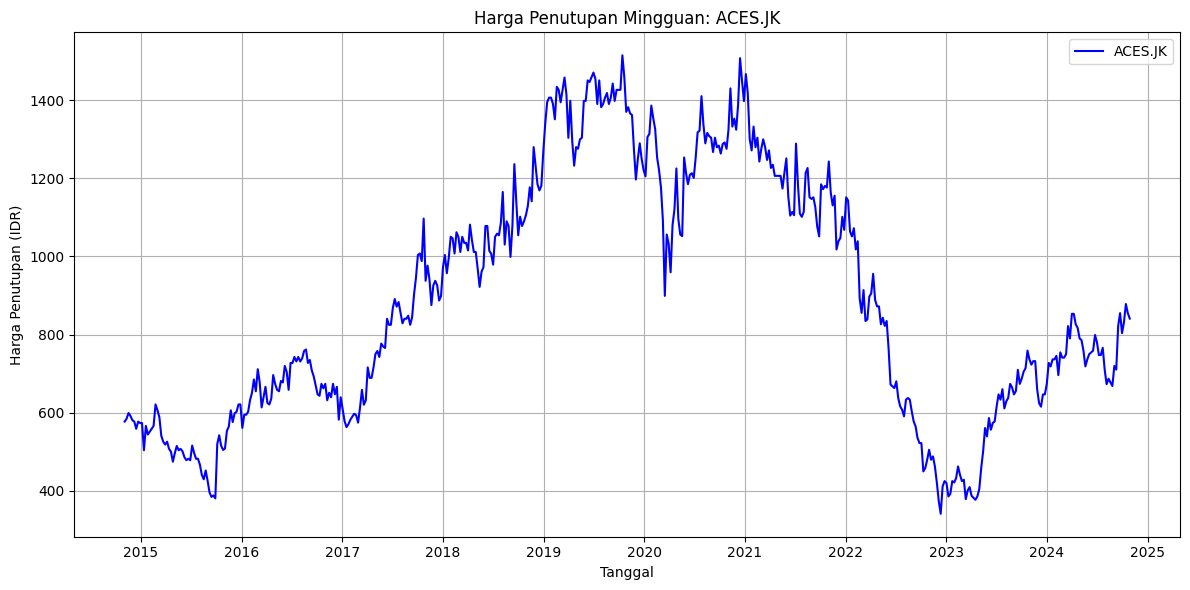

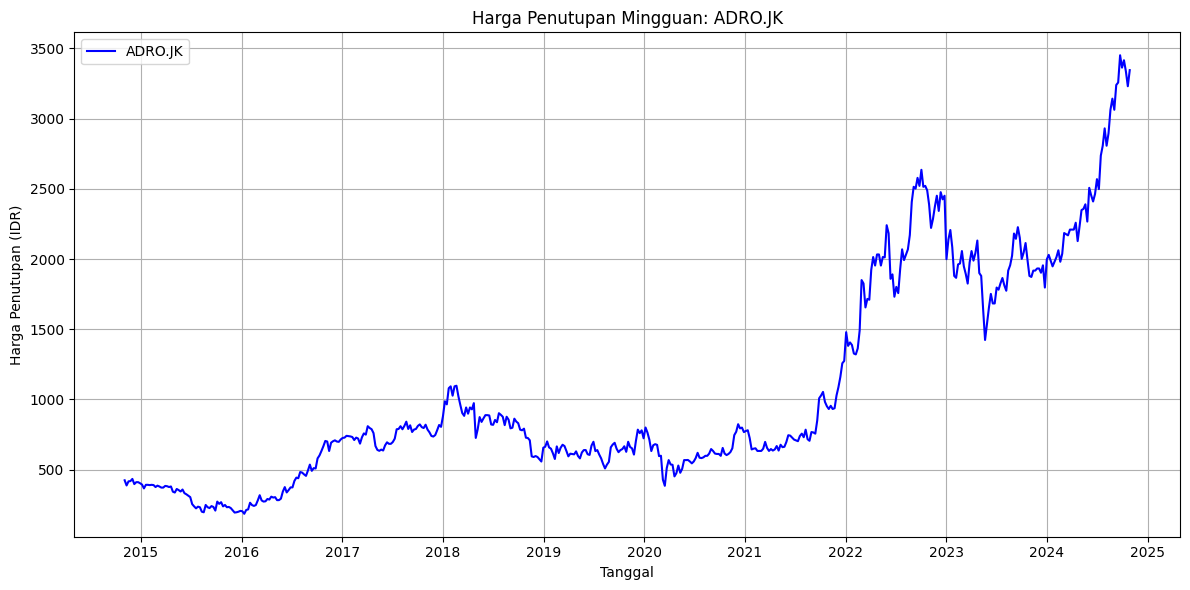

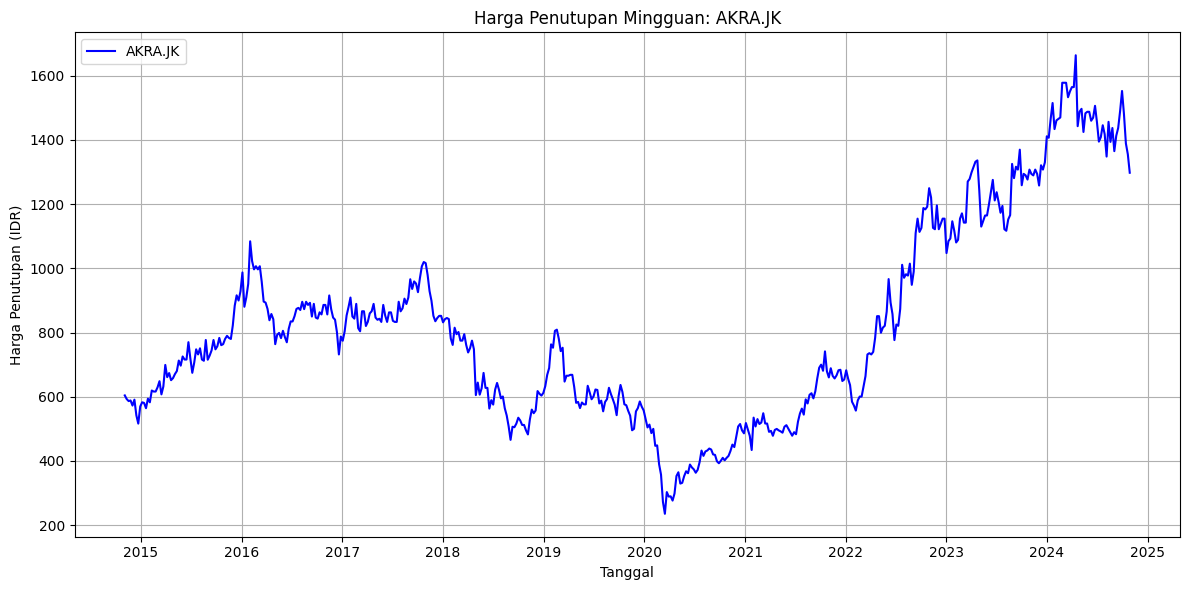

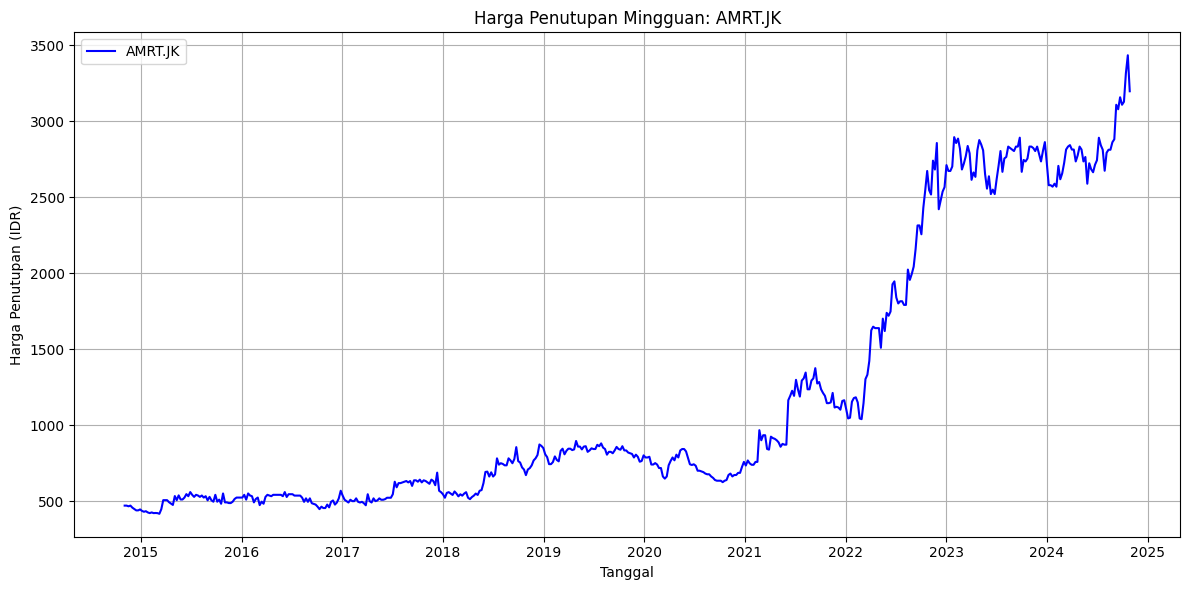

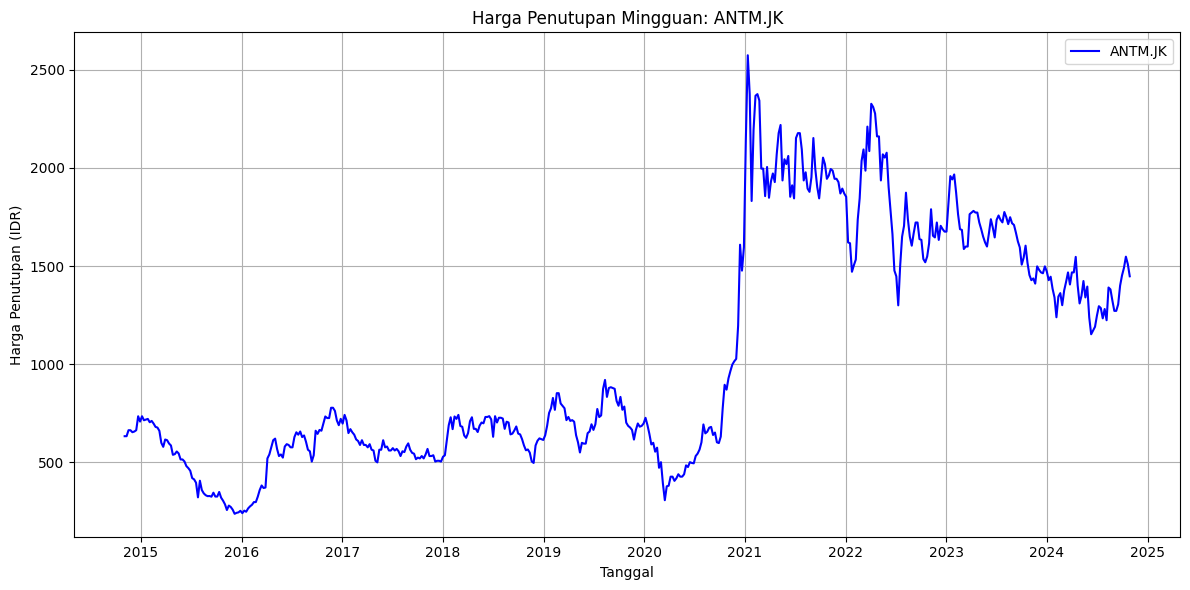

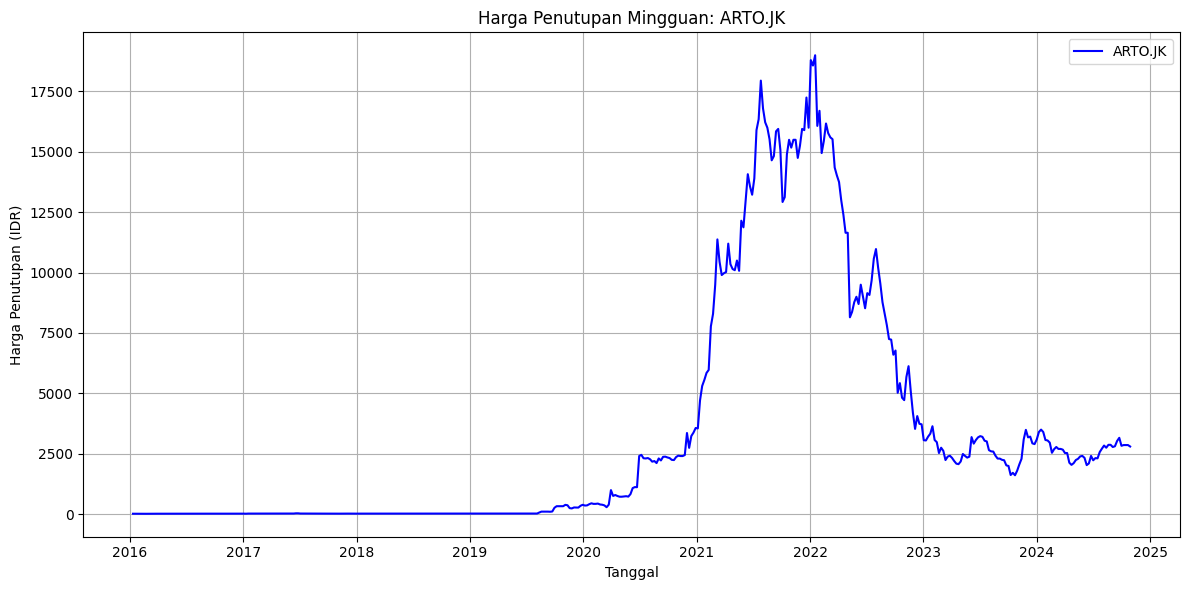

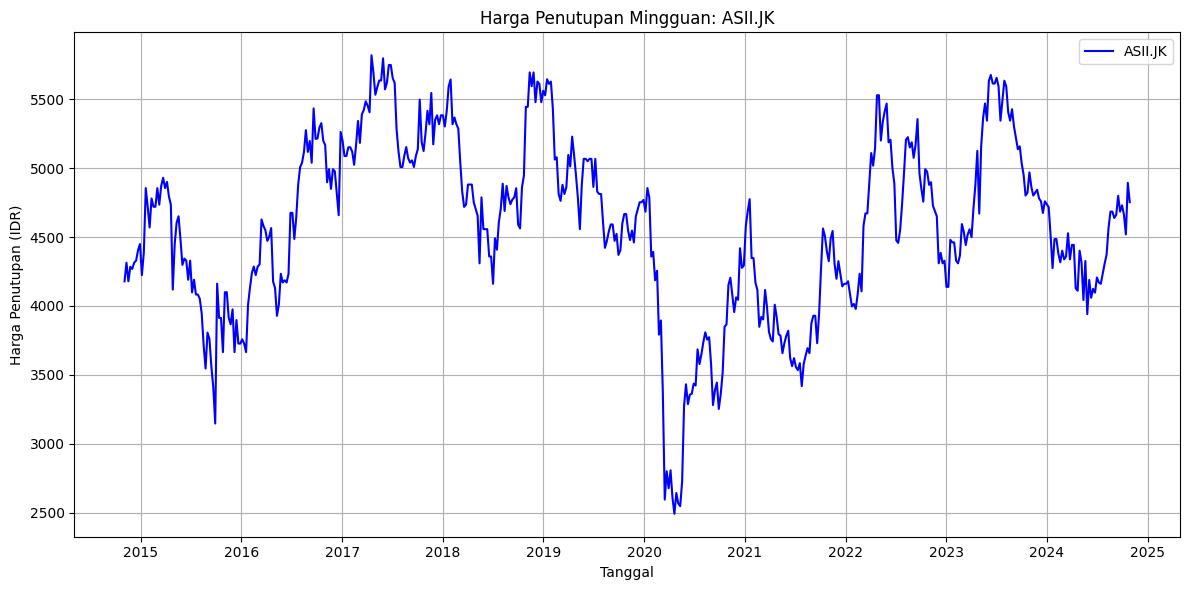

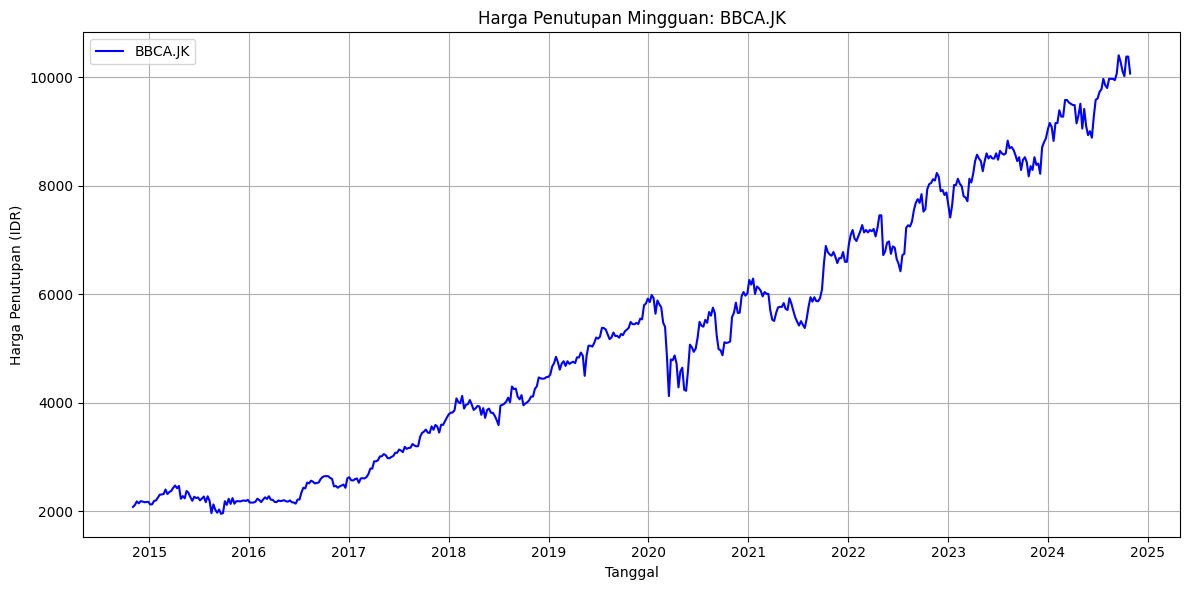

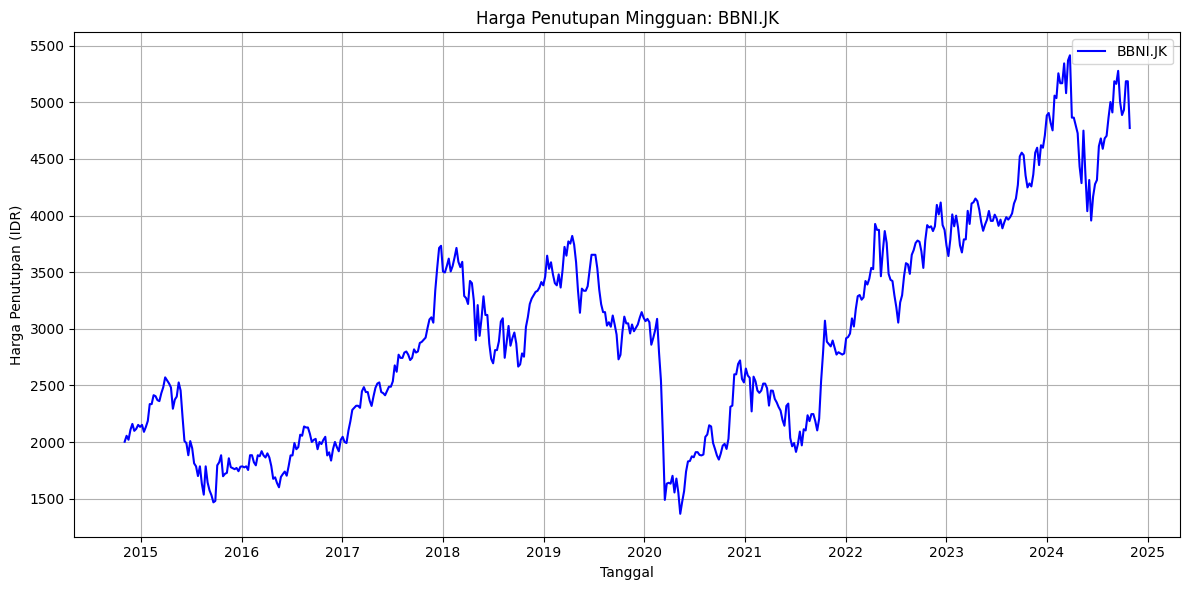

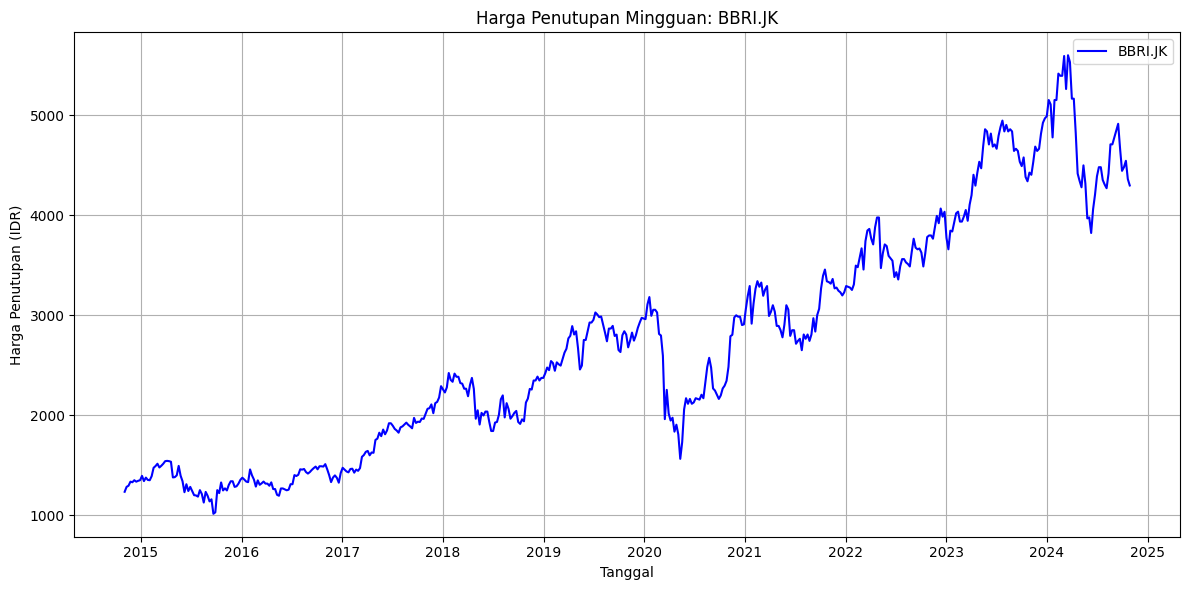

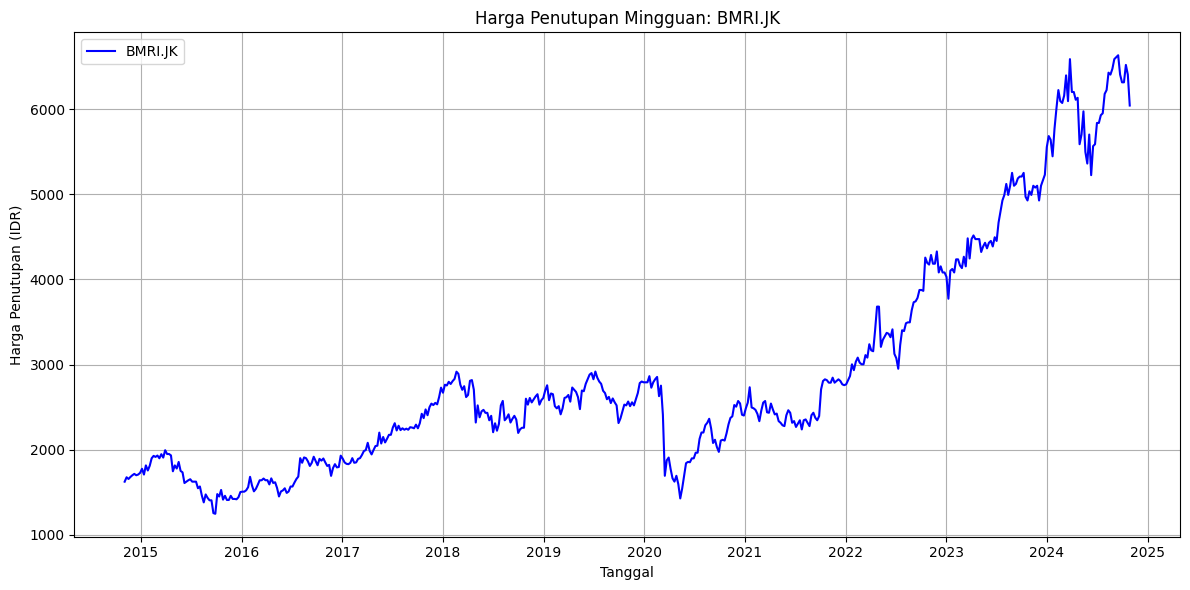

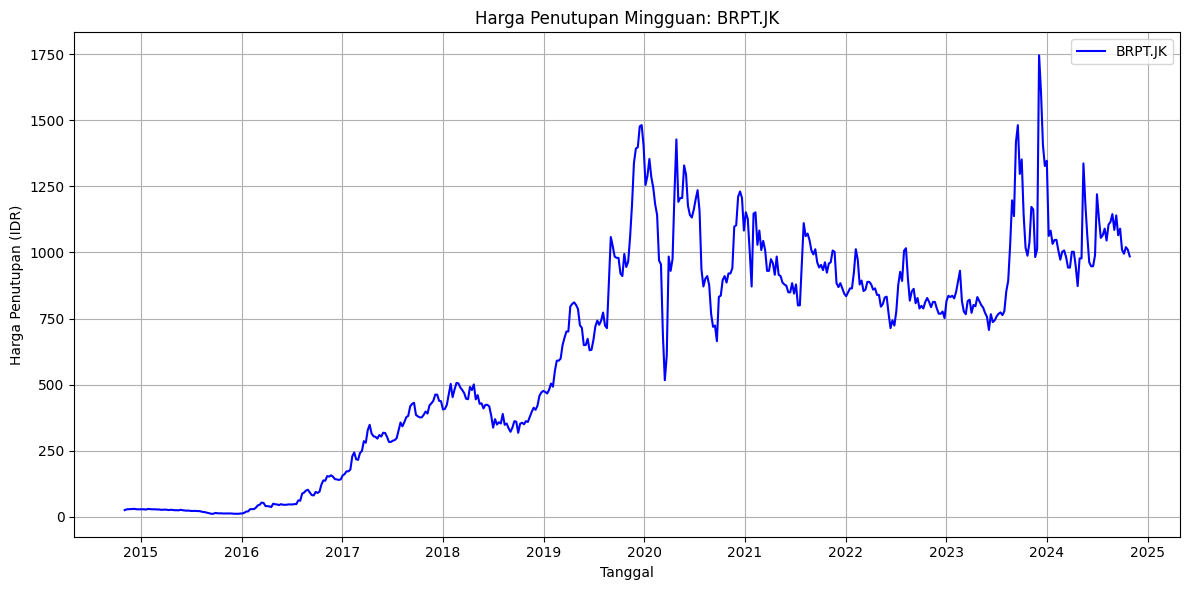

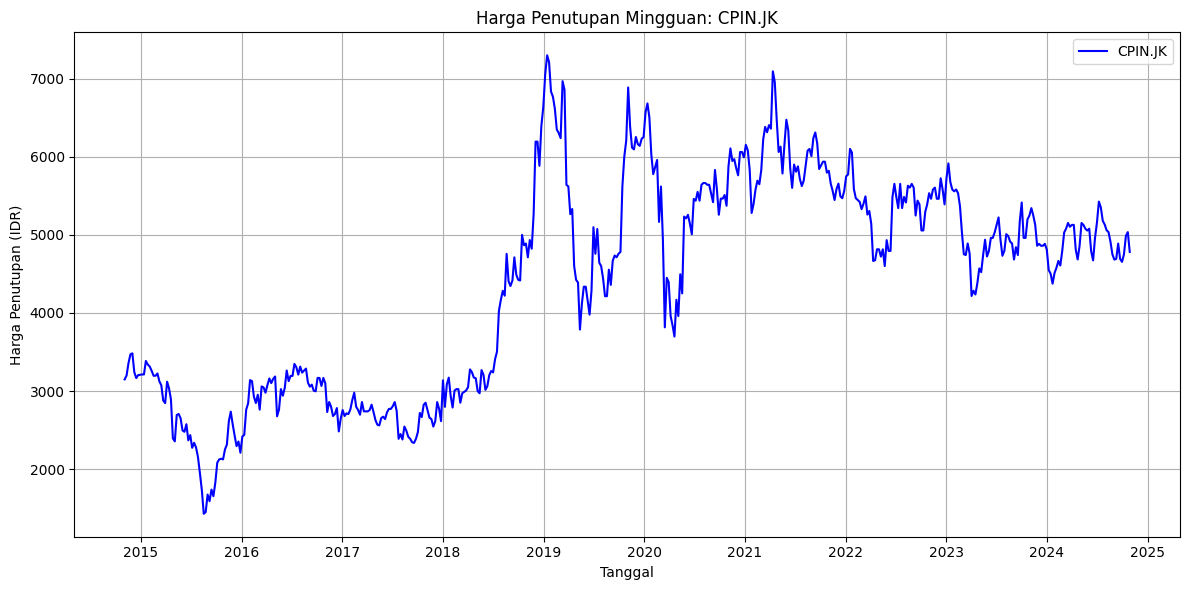

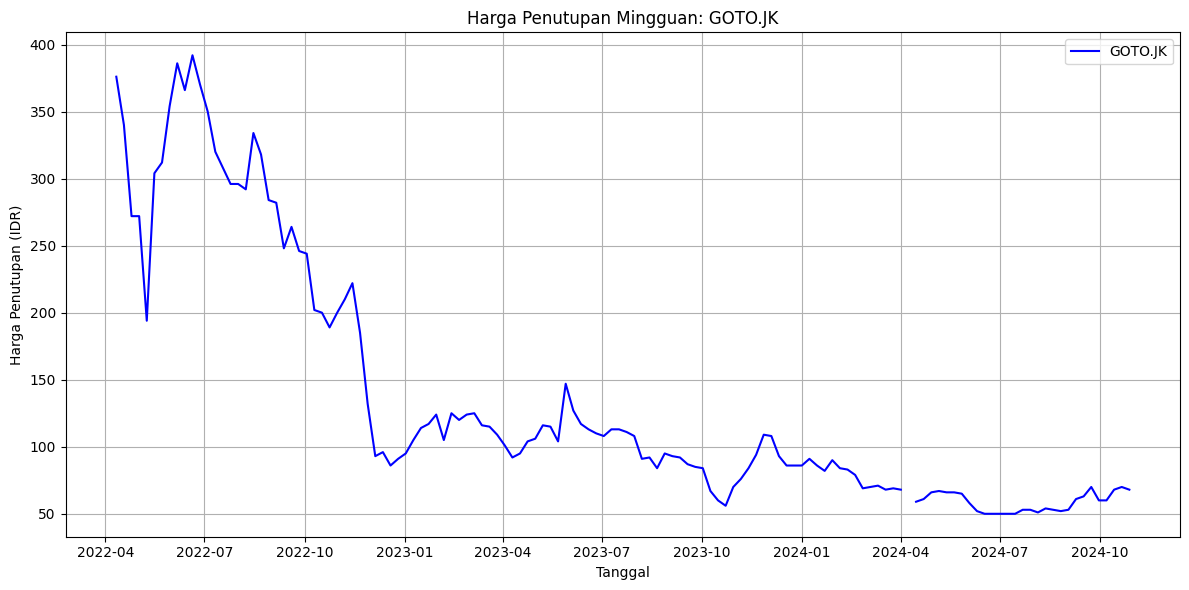

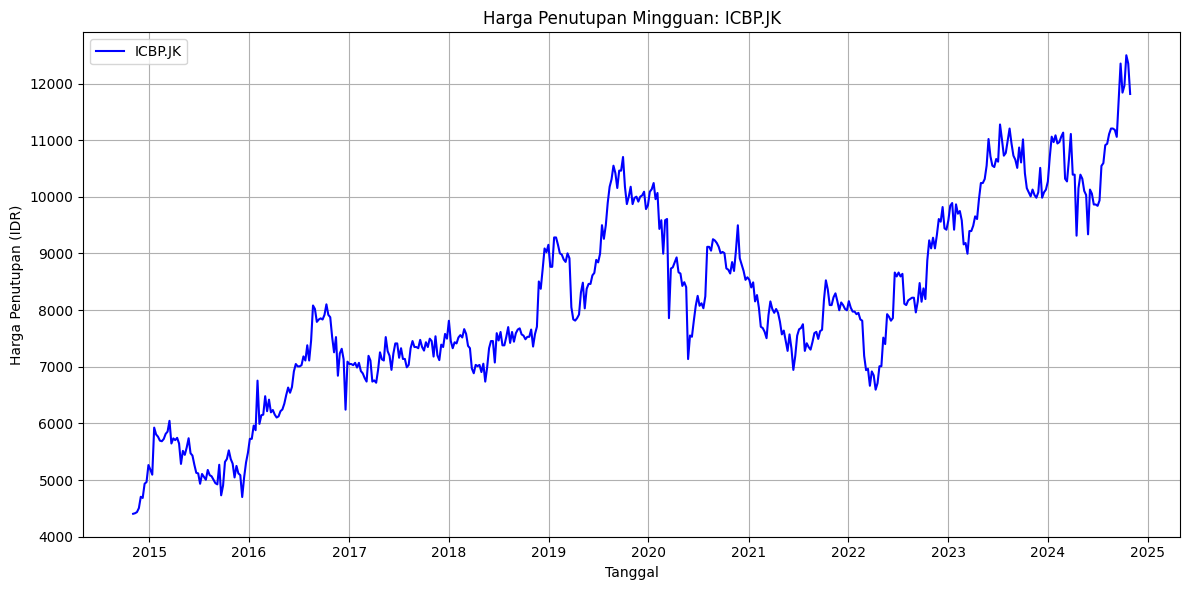

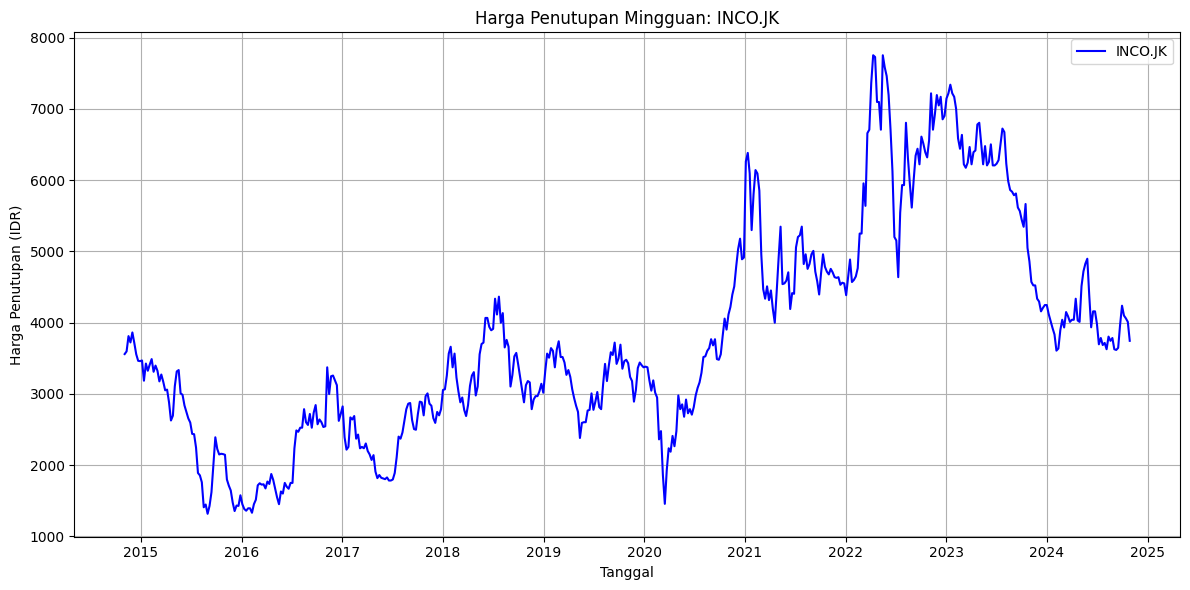

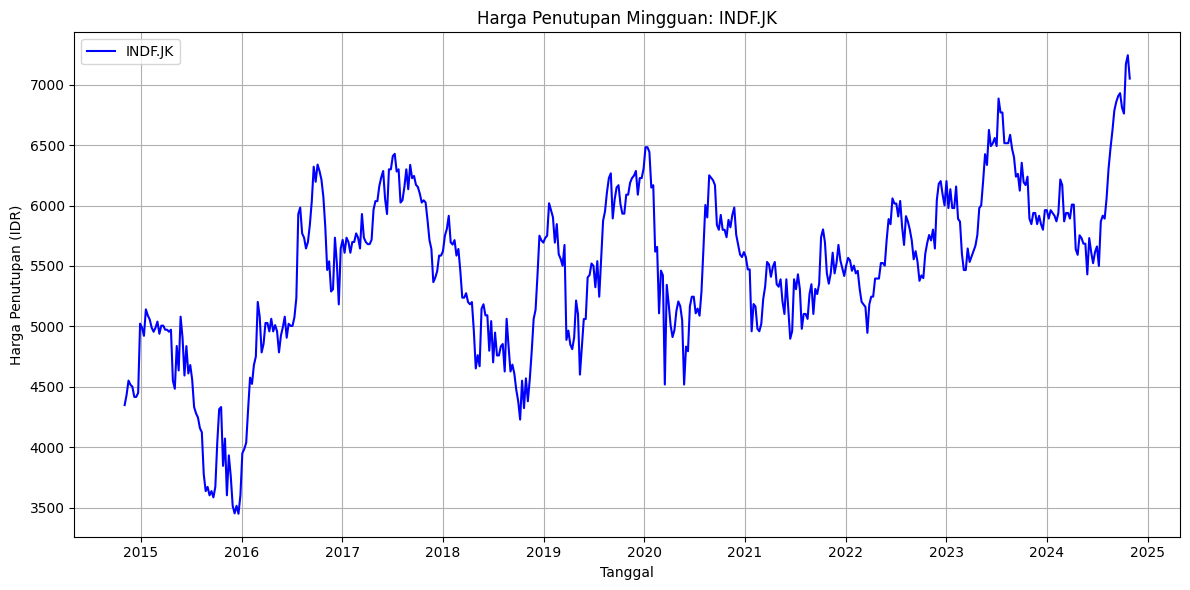

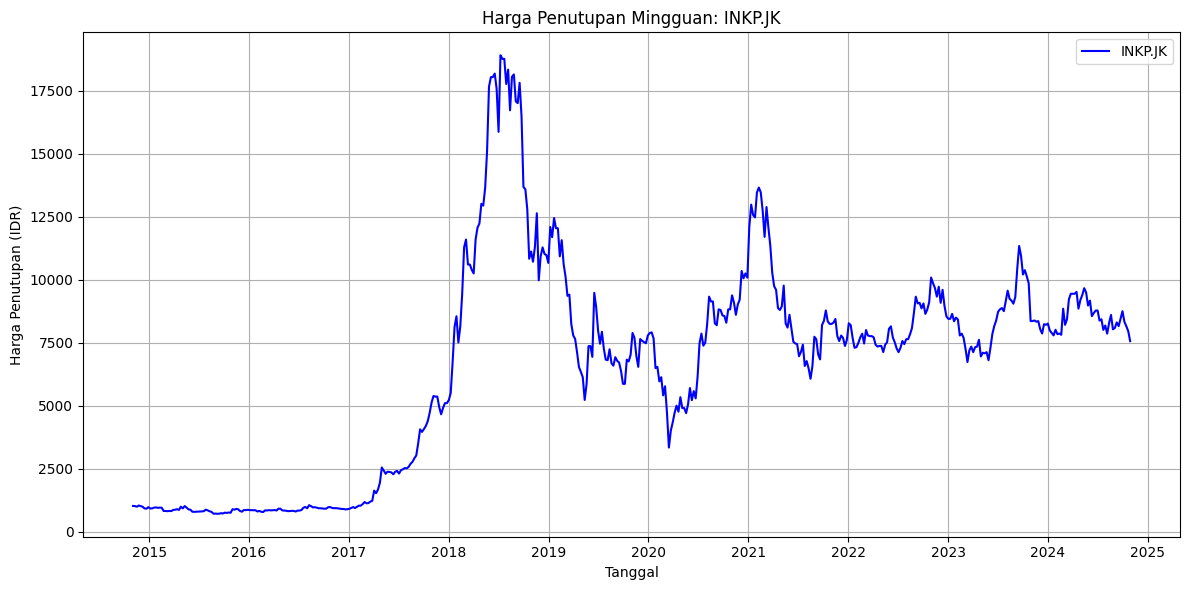

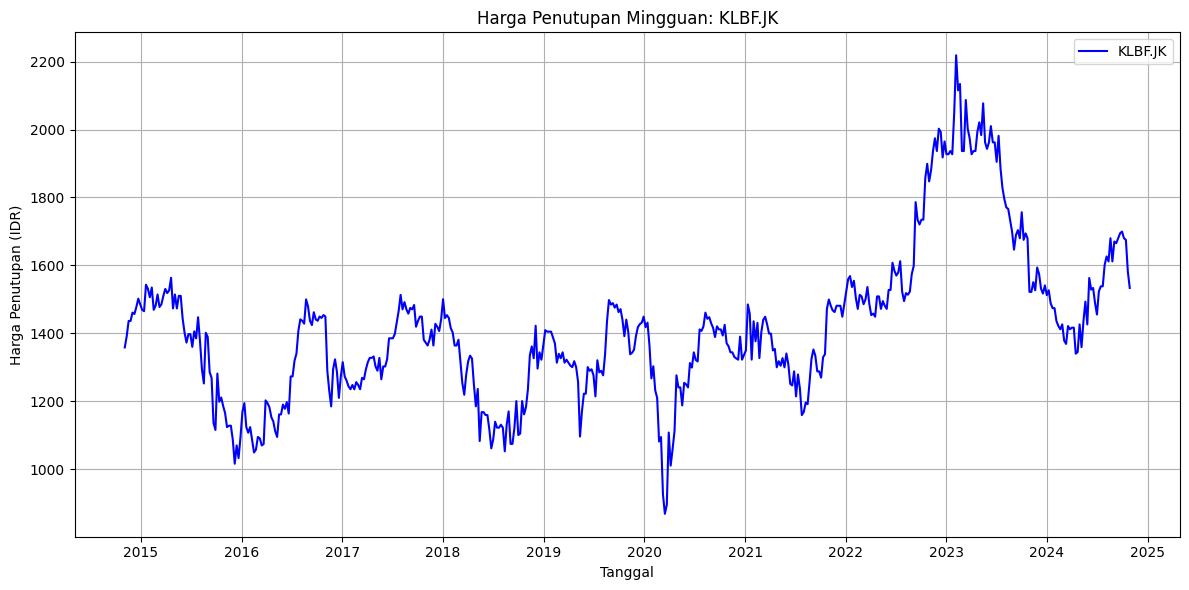

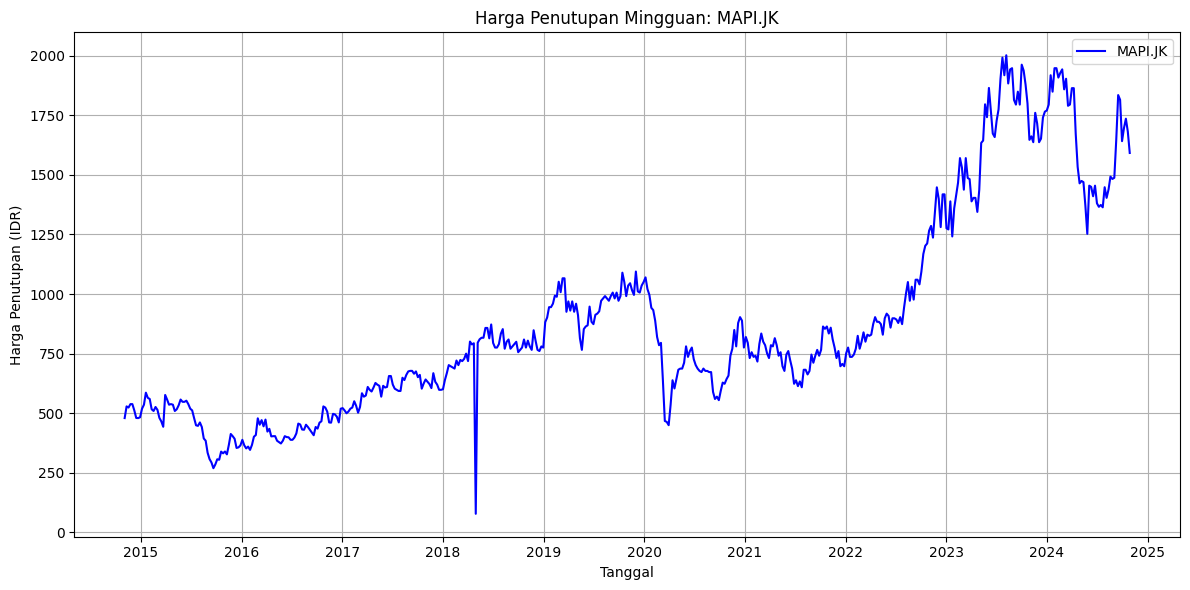

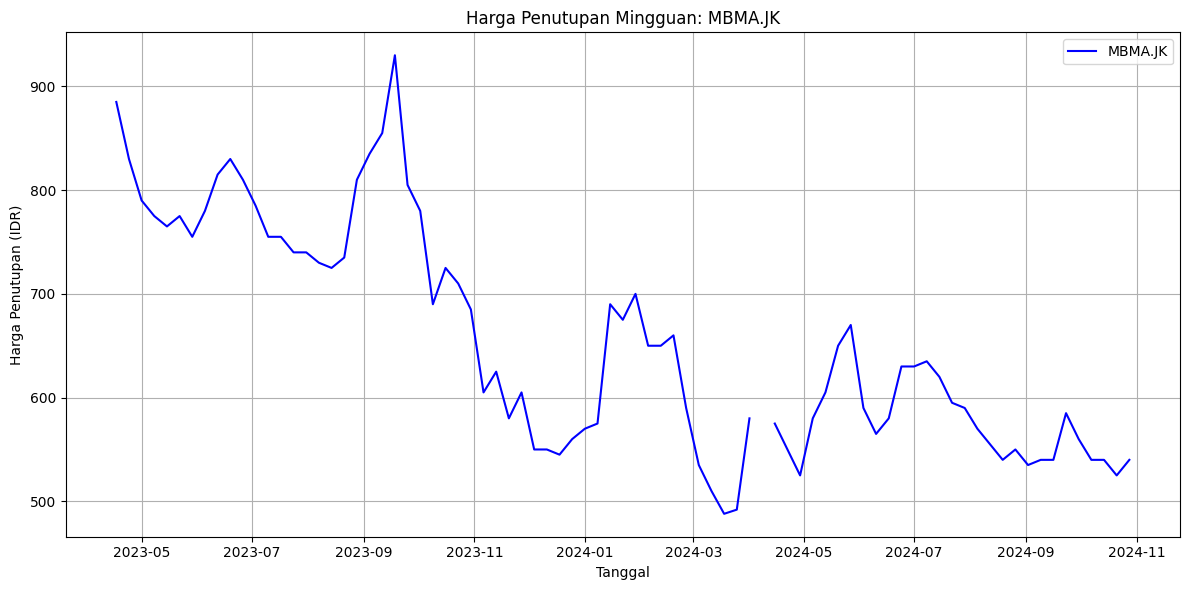

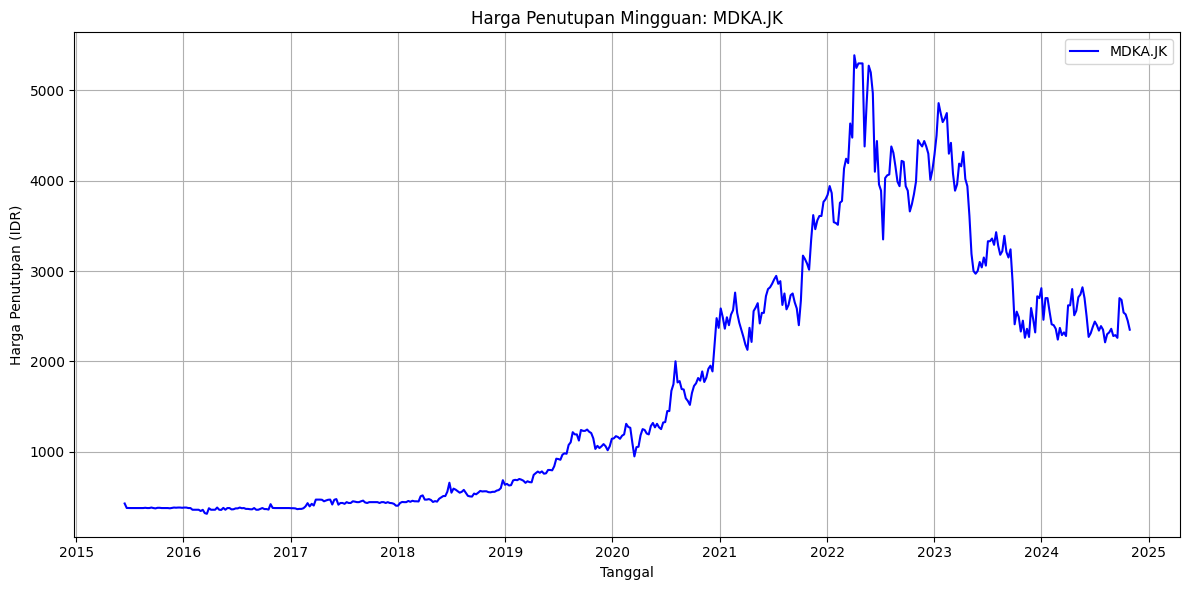

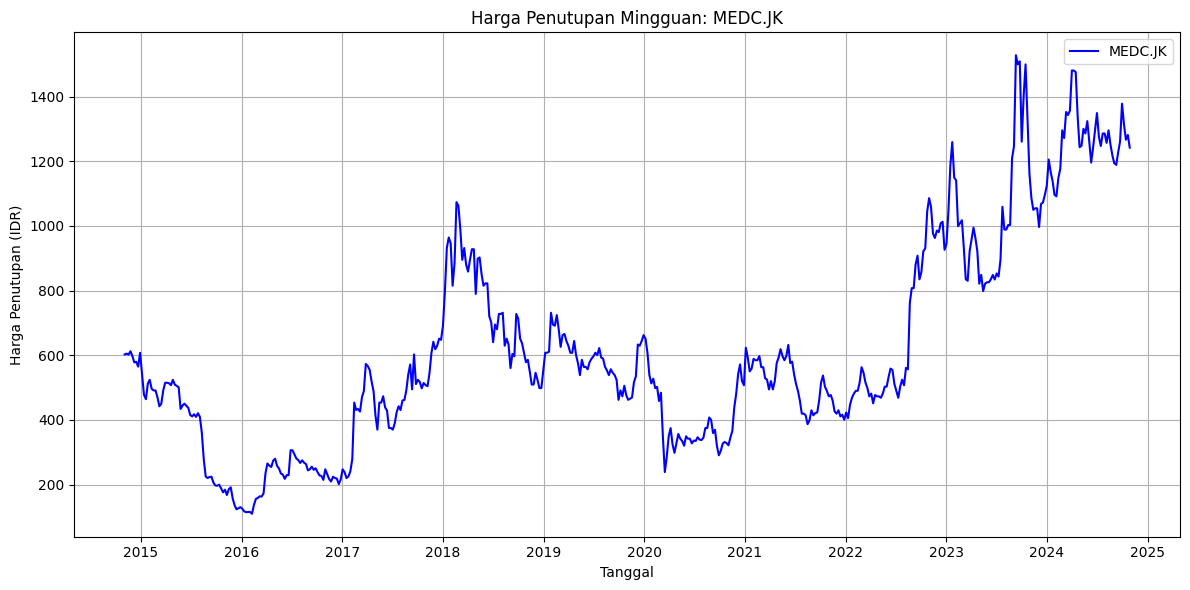

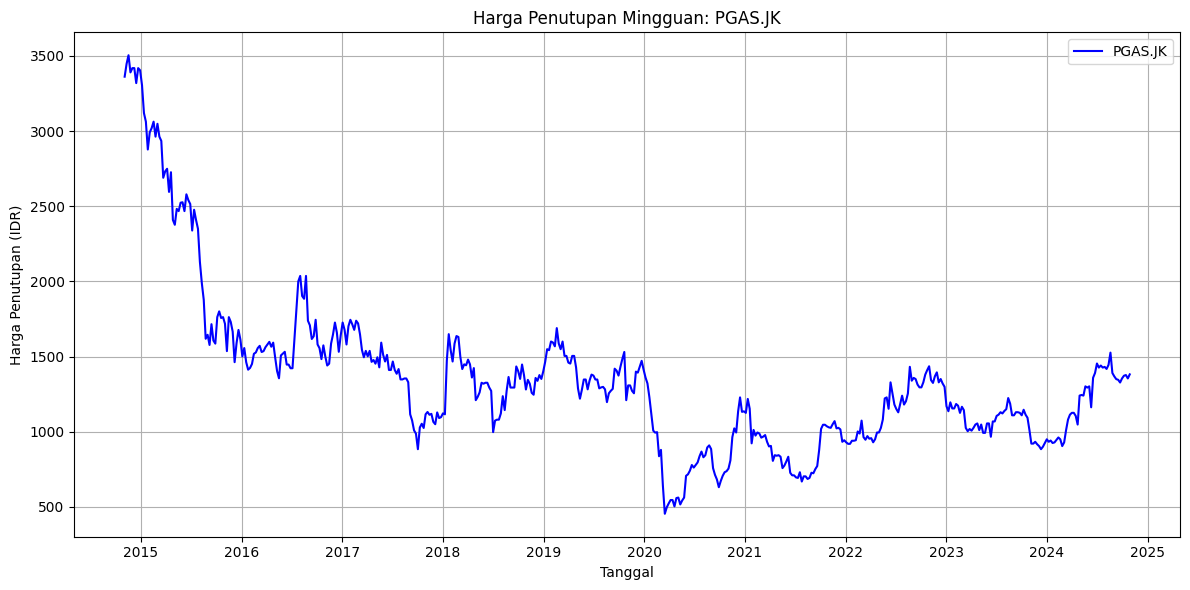

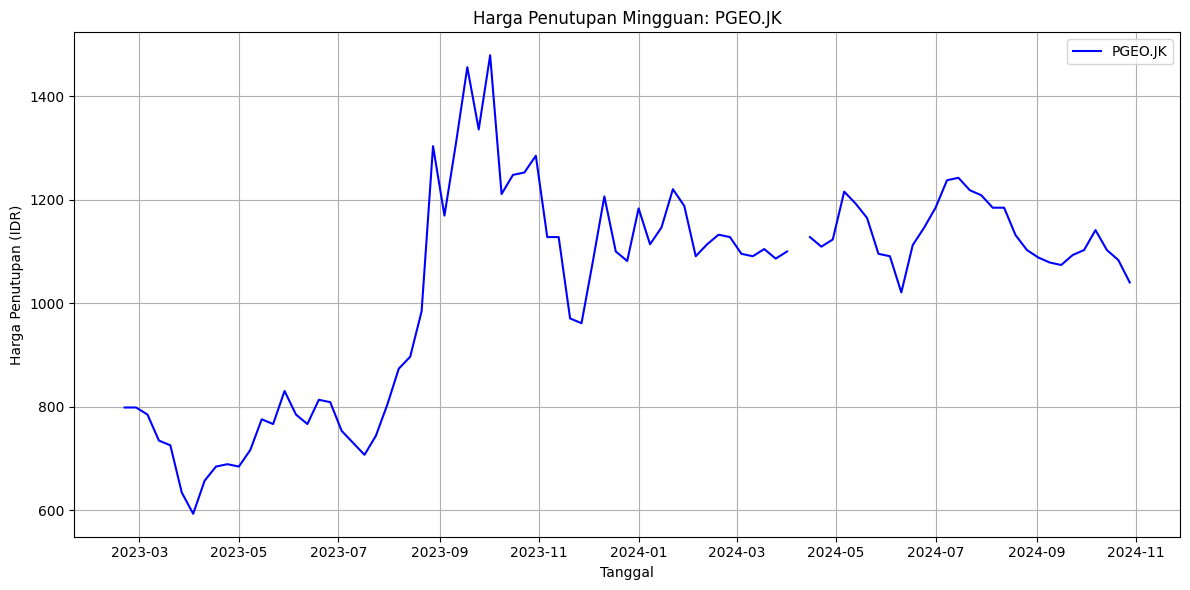

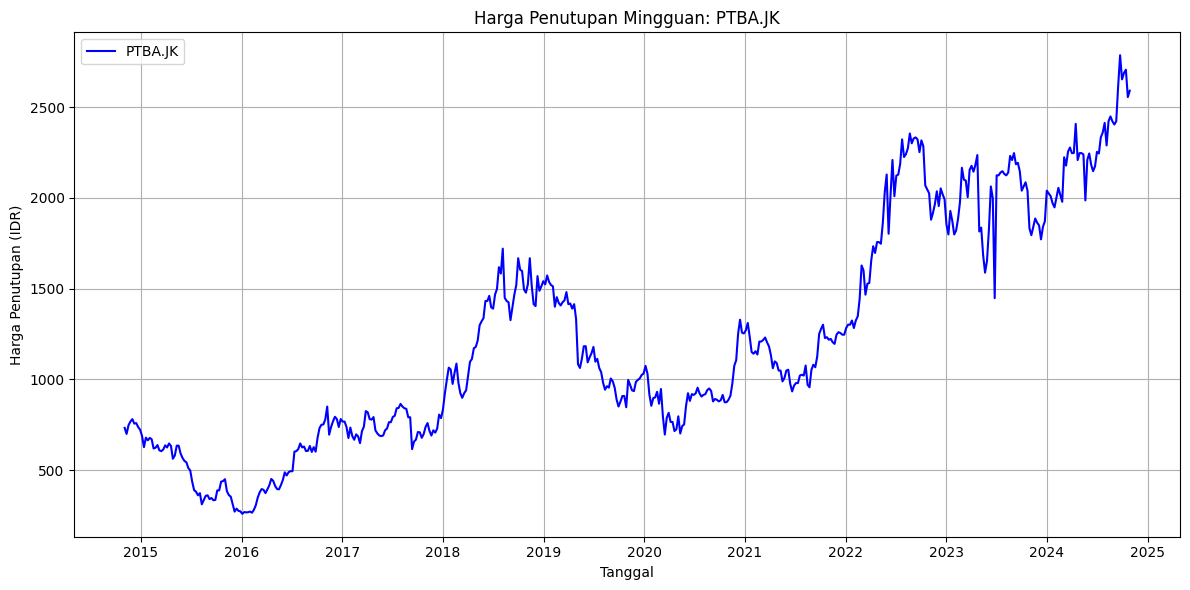

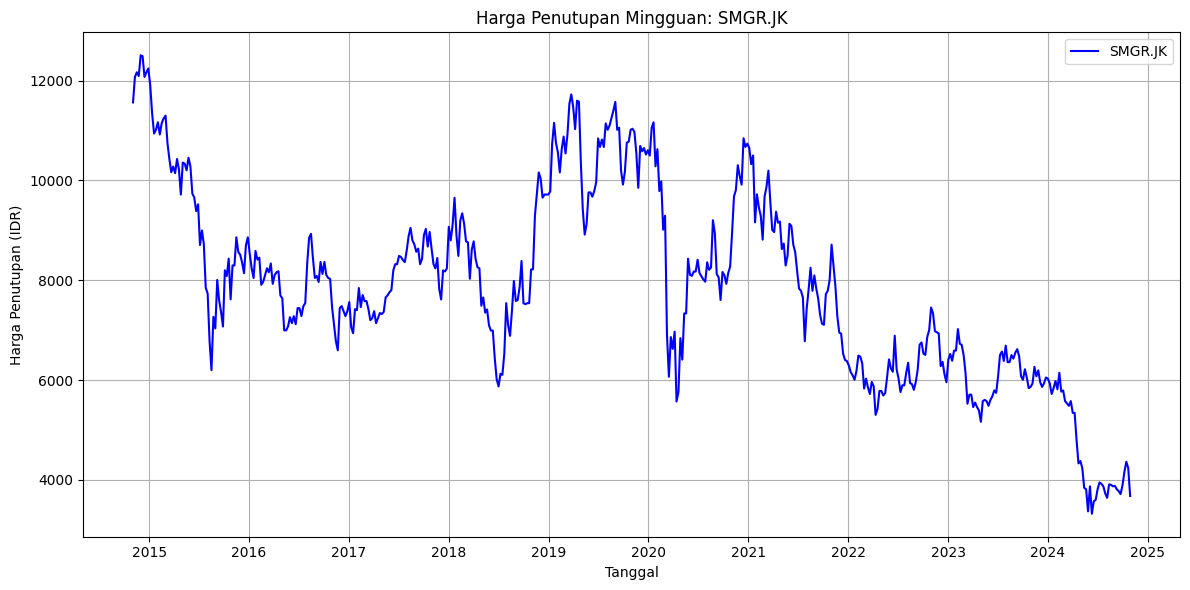

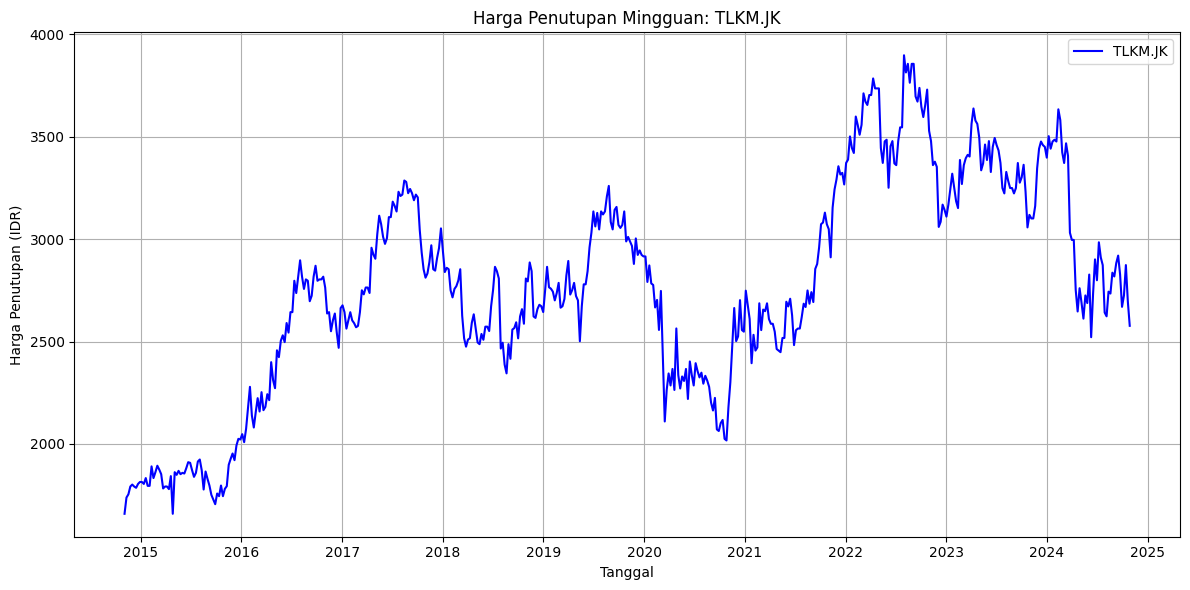

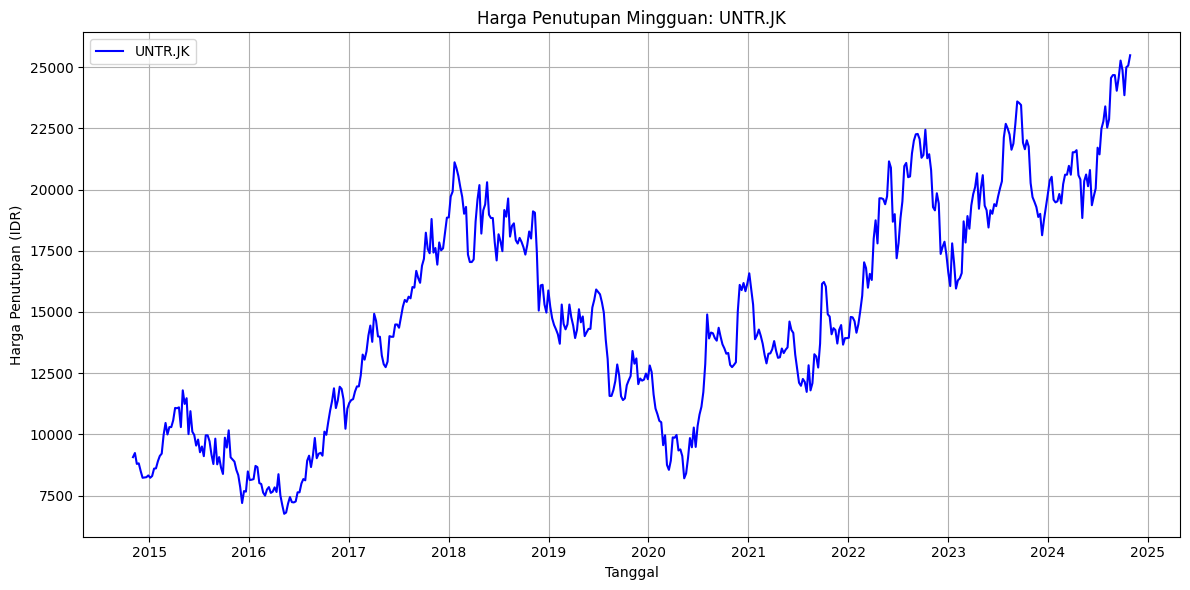

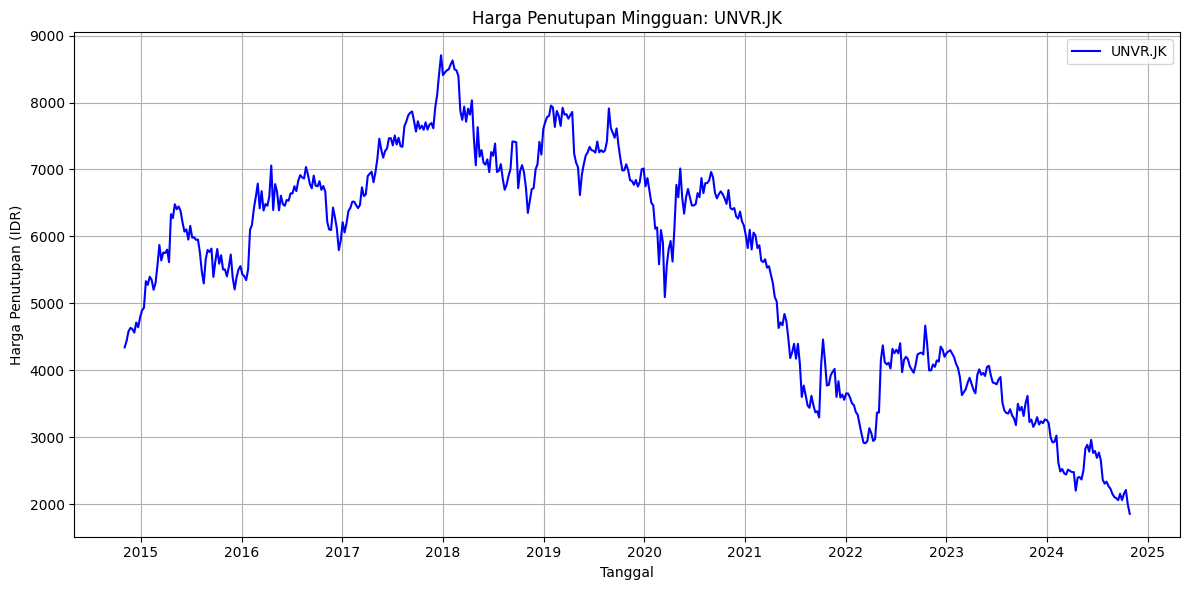

In [3]:
# Plot harga penutupan mingguan
for ticker in tickers:
    if ticker in data.columns:
        plt.figure(figsize=(12, 6))
        plt.plot(data.index, data[ticker], label=f'{ticker}', color='blue')
        plt.title(f'Harga Penutupan Mingguan: {ticker}')
        plt.xlabel('Tanggal')
        plt.ylabel('Harga Penutupan (IDR)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

##Dataset ESG

In [4]:
# ESG Score
esg_scores = {
    'ACES.JK': 19.65, 'ADRO.JK': 42.72, 'AKRA.JK': 23.79, "AMRT.JK": 31.93, "ANTM.JK": 42.06,
    "ASII.JK": 35.60, 'BBCA.JK': 21.51, 'BBNI.JK': 23.17, 'BBRI.JK': 17.83,
    'BMRI.JK': 27.64, 'BRPT.JK': 24.21, 'CPIN.JK': 44.48, 'ICBP.JK': 34.80,
    'INCO.JK': 29.41, 'INDF.JK': 36.06, 'INKP.JK': 26.44, 'KLBF.JK': 33.27, 'MAPI.JK': 20.31,
    'MEDC.JK': 29.08, 'PGAS.JK': 26.32,
    'PTBA.JK': 33.87, 'SMGR.JK': 23.05, 'TLKM.JK': 28.18, 'UNTR.JK': 38.81, 'UNVR.JK': 18.21,
}

# Konversi ke DataFrame
esg_df = pd.DataFrame(list(esg_scores.items()), columns=['Ticker', 'ESG_Score'])
# Mengubah data menjadi CSV
csv_file_path = 'stock_data_esg.csv'
esg_df.to_csv(csv_file_path)
esg_df


,Ticker,ESG_Score
0,ACES.JK,19.65
1,ADRO.JK,42.72
2,AKRA.JK,23.79
3,AMRT.JK,31.93
4,ANTM.JK,42.06
5,ASII.JK,35.60
6,BBCA.JK,21.51
7,BBNI.JK,23.17
8,BBRI.JK,17.83
9,BMRI.JK,27.64


In [5]:
#Kategorikan berdasarkan ESG Score
categories = {
    '0-10': esg_df[esg_df['ESG_Score'] <= 10],
    '11-20': esg_df[(esg_df['ESG_Score'] > 10) & (esg_df['ESG_Score'] <= 20)],
    '21-30': esg_df[(esg_df['ESG_Score'] > 20) & (esg_df['ESG_Score'] <= 30)],
    '31-40': esg_df[(esg_df['ESG_Score'] > 30) & (esg_df['ESG_Score'] <= 40)],
    '>41': esg_df[esg_df['ESG_Score'] > 41],
}

categories

{'0-10': Empty DataFrame
 Columns: [Ticker, ESG_Score]
 Index: [],
 '11-20':      Ticker  ESG_Score
 0   ACES.JK      19.65
 8   BBRI.JK      17.83
 24  UNVR.JK      18.21,
 '21-30':      Ticker  ESG_Score
 2   AKRA.JK      23.79
 6   BBCA.JK      21.51
 7   BBNI.JK      23.17
 9   BMRI.JK      27.64
 10  BRPT.JK      24.21
 13  INCO.JK      29.41
 15  INKP.JK      26.44
 17  MAPI.JK      20.31
 18  MEDC.JK      29.08
 19  PGAS.JK      26.32
 21  SMGR.JK      23.05
 22  TLKM.JK      28.18,
 '31-40':      Ticker  ESG_Score
 3   AMRT.JK      31.93
 5   ASII.JK      35.60
 12  ICBP.JK      34.80
 14  INDF.JK      36.06
 16  KLBF.JK      33.27
 20  PTBA.JK      33.87
 23  UNTR.JK      38.81,
 '>41':      Ticker  ESG_Score
 1   ADRO.JK      42.72
 4   ANTM.JK      42.06
 11  CPIN.JK      44.48}

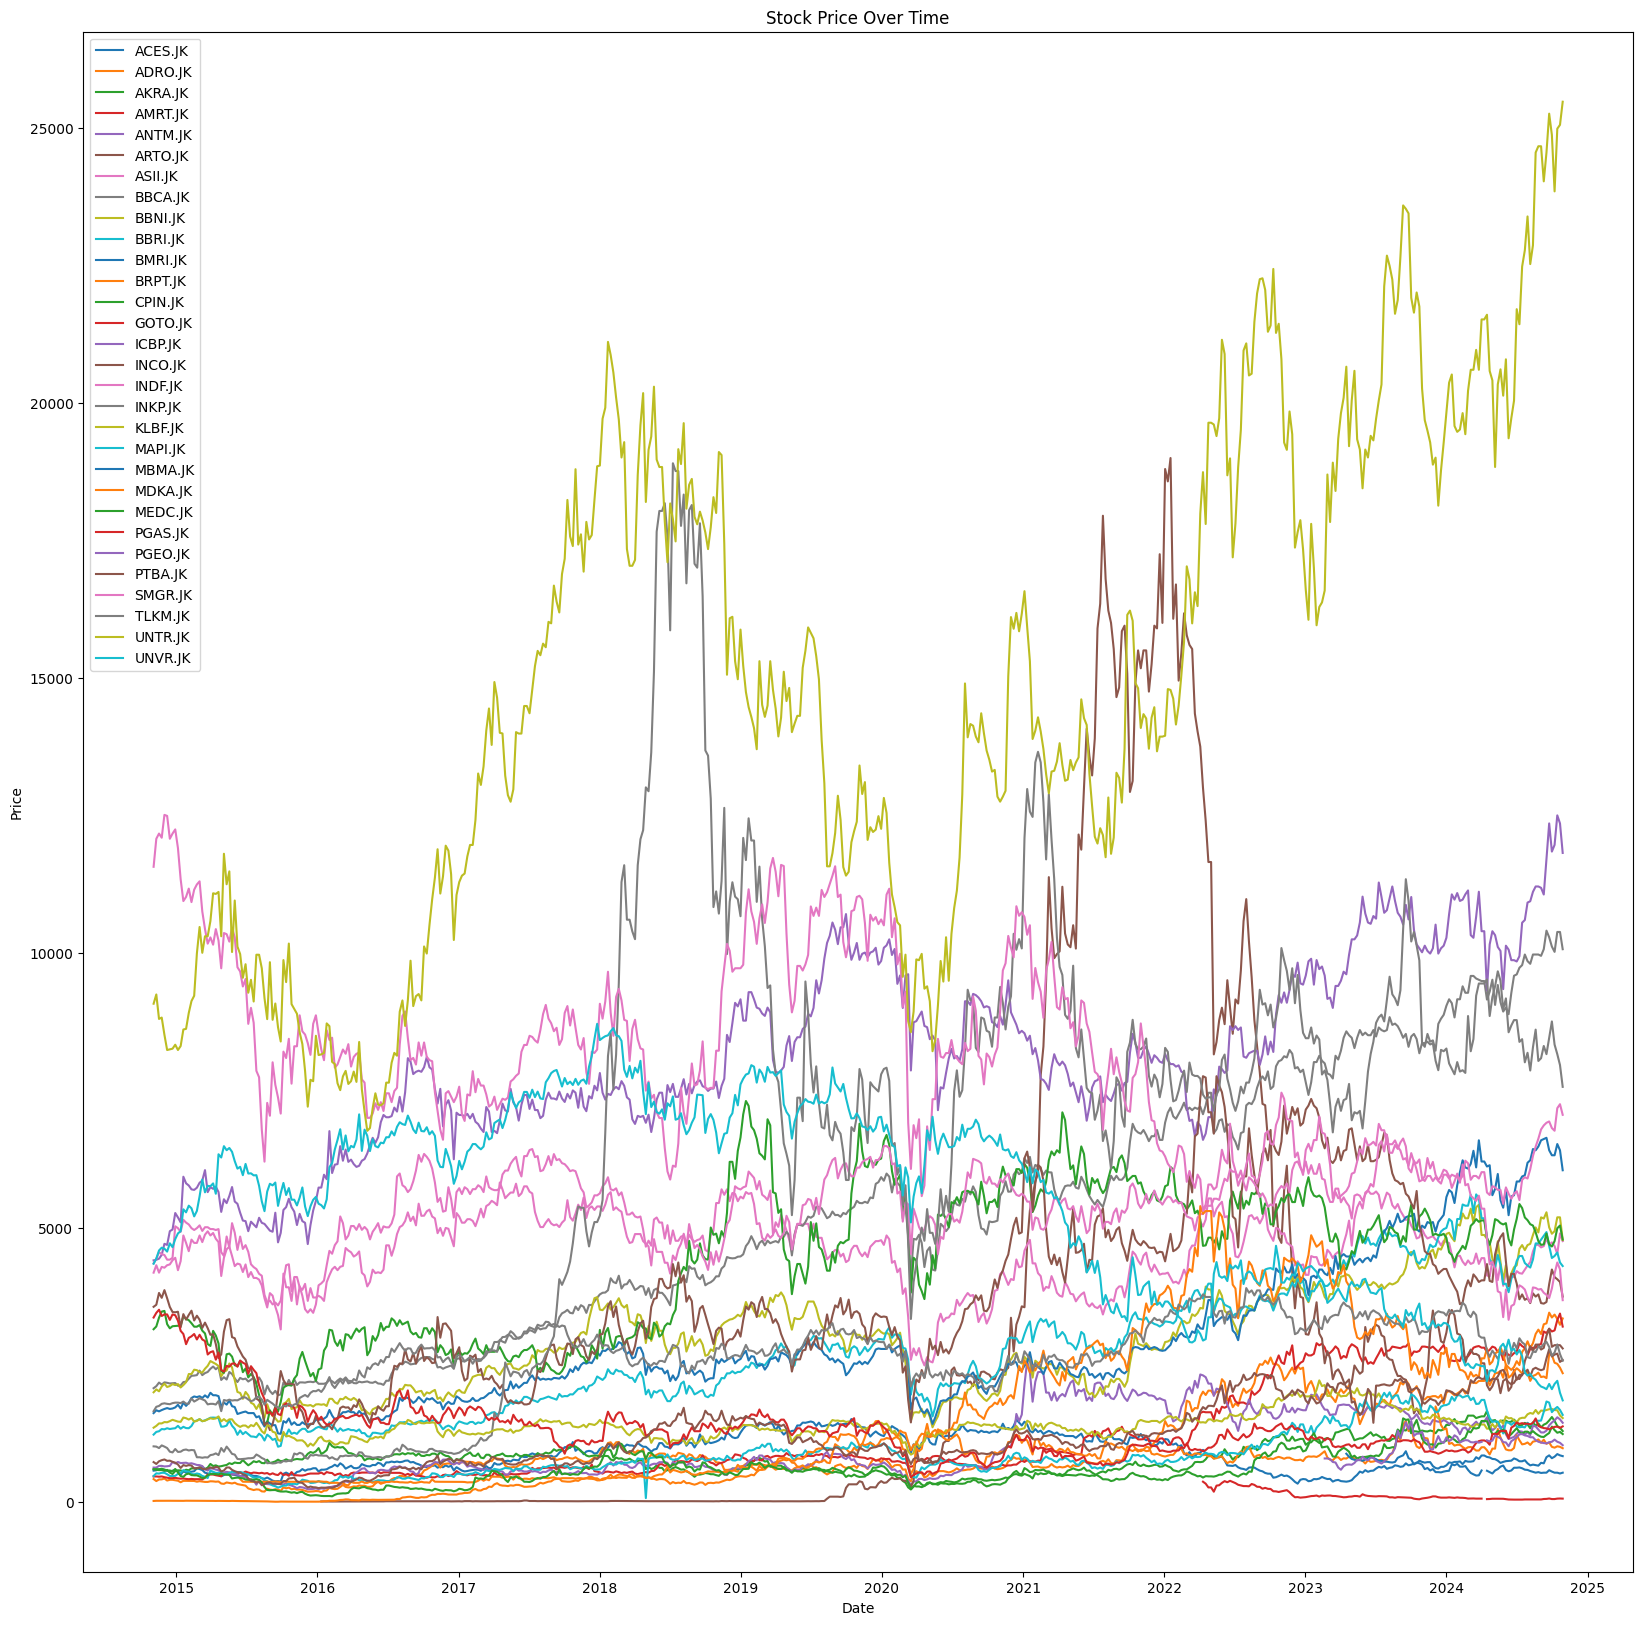

In [6]:
plt.figure(figsize = (20,20))
plt.plot(data)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Over Time")
plt.legend(data.columns)
plt.show()

# Pra Pemrosesan Data

## Pembersihan Data

In [7]:
# Mengatur index menjadi format tanggal
data.index = data.index.date
# Simpan daftar original ticker sebelum memproses data
original_tickers = data.columns.tolist()

# Tangani data yang hilang
print("Jumlah kolom sebelum penanganan data kosong:", len(data.columns))
data_clean = data.dropna(axis=1, thresh=len(data))
print("Jumlah kolom setelah penanganan data kosong:", len(data_clean.columns))

# Identifikasi ticker yang di-drop
remaining_tickers = data_clean.columns.tolist()
dropped_tickers = [ticker for ticker in original_tickers if ticker not in remaining_tickers]

# Tampilkan ticker yang di-drop
print("\nSaham yang di-drop karena data tidak lengkap:")
for ticker in dropped_tickers:
    print(f"- {ticker}")

# Lanjutkan dengan data yang sudah dibersihkan
data = data_clean
# Menyimpan data menjadi file CSV
csv_file_path = 'stock_data_adj_close.csv'
data.to_csv(csv_file_path)

# Menampilkan beberapa data awal
print("Data Saham (Adj Close):")
data = data.dropna(axis=1, thresh=len(data))
data = data.round(0).astype(int)
data.head()

Jumlah kolom sebelum penanganan data kosong: 30
Jumlah kolom setelah penanganan data kosong: 25

Saham yang di-drop karena data tidak lengkap:
- ARTO.JK
- GOTO.JK
- MBMA.JK
- MDKA.JK
- PGEO.JK
Data Saham (Adj Close):


Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
2014-11-03,577,424,604,471,633,4179,2077,2003,1233,1624,...,1019,1358,479,603,3362,732,11563,1659,9072,4342
2014-11-10,584,387,593,471,633,4314,2114,2055,1282,1675,...,1014,1391,528,605,3448,699,12073,1738,9240,4436
2014-11-17,599,416,586,467,664,4179,2179,2020,1294,1655,...,988,1436,524,602,3505,747,12168,1754,8795,4582
2014-11-24,591,418,588,471,664,4284,2143,2108,1334,1679,...,1036,1436,538,613,3391,768,12092,1792,8819,4633
2014-12-01,580,434,572,458,654,4269,2183,2160,1328,1699,...,1014,1461,538,598,3419,781,12508,1802,8506,4615


## Return Saham

$$
R = \frac{P_t - P_{t-1}}{P_{t-1}}
$$  
di mana:
- $R$  = Return saham
- $P_t$ = Harga saham saat ini  
- $P_{t-1}$ = Harga saham sebelumnya

---

In [8]:
#Mencari Return Stock
return_stock = data.pct_change()
return_stock

Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
2014-11-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-11-10,0.012132,-0.087264,-0.018212,0.000000,0.000000,0.032304,0.017814,0.025961,0.039740,0.031404,...,-0.004907,0.024300,0.102296,0.003317,0.025580,-0.045082,0.044106,0.047619,0.018519,0.021649
2014-11-17,0.025685,0.074935,-0.011804,-0.008493,0.048973,-0.031293,0.030747,-0.017032,0.009360,-0.011940,...,-0.025641,0.032351,-0.007576,-0.004959,0.016531,0.068670,0.007869,0.009206,-0.048160,0.032913
2014-11-24,-0.013356,0.004808,0.003413,0.008565,0.000000,0.025126,-0.016521,0.043564,0.030912,0.014502,...,0.048583,0.000000,0.026718,0.018272,-0.032525,0.028112,-0.006246,0.021665,0.002729,0.011131
2014-12-01,-0.018613,0.038278,-0.027211,-0.027601,-0.015060,-0.003501,0.018665,0.024668,-0.004498,0.011912,...,-0.021236,0.017409,0.000000,-0.024470,0.008257,0.016927,0.034403,0.005580,-0.035492,-0.003885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-30,-0.060819,-0.025782,0.041611,-0.015516,0.037857,0.009605,-0.016438,-0.022991,-0.046945,-0.014205,...,0.035140,0.002950,-0.095317,0.091918,0.020331,-0.047739,0.046812,-0.055536,-0.015357,-0.044104
2024-10-07,0.034869,0.015760,-0.046392,0.006433,0.026153,-0.014376,-0.009593,0.009413,0.008097,0.000000,...,-0.048120,-0.011765,0.032887,-0.045718,0.013284,0.013570,0.069391,0.020599,-0.041243,0.046139
2024-10-14,0.056558,-0.023126,-0.061486,0.059764,0.038229,-0.030674,0.036146,0.051287,0.014279,0.032304,...,-0.020893,-0.002976,0.023585,-0.036502,0.003642,0.006322,0.048786,0.054679,0.047797,0.026462
2024-10-21,-0.026196,-0.031765,-0.024478,0.035887,-0.024548,0.082983,0.000000,0.000000,-0.040255,-0.017334,...,-0.024283,-0.055522,-0.031682,0.011839,-0.016691,-0.055802,-0.028643,-0.061239,0.002801,-0.098598


## Expected Return Mingguan

Rumus:

$$
E(R) = \frac{1}{n} \sum_{t=1}^{n} R_t
$$

di mana:

<div style="margin-left: 30px; display: flex; flex-direction: column;">
  <p>- \( E(R) \) &nbsp;: Expected return saham</p>
  <p>- \( n \) &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;: Jumlah periode </p>
  <p>- \( R_t \) &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;: Return pada periode ke-\( t \)</p>
</div>


In [ ]:
#Expected Return Mingguan
expected_returns = return_stock.mean()
ExpectedReturns = expected_returns
expected_returns

,0
Ticker,
ACES.JK,0.002148
ADRO.JK,0.006091
AKRA.JK,0.002732
AMRT.JK,0.004735
ANTM.JK,0.003837
ASII.JK,0.001137
BBCA.JK,0.003449
BBNI.JK,0.002711
BBRI.JK,0.003247


In [ ]:
#Expected Return Tahunan
expected_annual_returns = expected_returns * 52  # karena ada 52 minggu dalam setahun
expected_annual_returns

,0
Ticker,
ACES.JK,0.111718
ADRO.JK,0.316716
AKRA.JK,0.142055
AMRT.JK,0.246234
ANTM.JK,0.199526
ASII.JK,0.059108
BBCA.JK,0.179333
BBNI.JK,0.140976
BBRI.JK,0.168823


## Risiko Saham

Rumus:

$$
\sigma = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (R_t - \bar{R})^2}
$$

di mana:
- $σ$ = **Standar deviasi** (risiko saham)
- $R_t$ = **Return** pada periode \( t \)
- $\bar{R}$ = **Rata-rata return** saham
- $n$ = **Jumlah periode** yang digunakan dalam perhitungan


In [ ]:
return_stock.dropna()

Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
2014-11-10,0.012132,-0.087264,-0.017915,0.000000,0.000000,0.032304,0.017814,0.025961,0.039740,0.031404,...,-0.004907,0.024300,0.102296,0.003317,0.025580,-0.045082,0.044106,0.047978,0.018519,0.021649
2014-11-17,0.025685,0.074935,-0.011609,-0.008493,0.048973,-0.031293,0.030747,-0.017032,0.009360,-0.011940,...,-0.025641,0.032351,-0.007576,-0.004959,0.016531,0.068670,0.007869,0.009259,-0.048160,0.032913
2014-11-24,-0.013356,0.004808,0.003356,0.008565,0.000000,0.025126,-0.016521,0.043564,0.030912,0.014502,...,0.048583,0.000000,0.026718,0.018272,-0.032525,0.028112,-0.006246,0.021407,0.002729,0.011131
2014-12-01,-0.018613,0.038278,-0.026756,-0.027601,-0.015060,-0.003501,0.018665,0.024668,-0.004498,0.011912,...,-0.021236,0.017409,0.000000,-0.024470,0.008257,0.016927,0.034403,0.005489,-0.035492,-0.003885
2014-12-08,-0.005172,-0.085253,0.032646,-0.019651,0.004587,0.010541,-0.003665,-0.028241,0.015813,0.009417,...,-0.025641,-0.002738,-0.048327,-0.033445,0.000000,-0.032010,-0.001519,-0.005459,-0.032448,-0.011484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-30,-0.060819,-0.025782,0.041611,-0.015516,0.037857,0.009605,-0.016438,-0.022991,-0.046945,-0.014205,...,0.035140,0.002950,-0.095317,0.091918,0.020331,-0.047739,0.046812,-0.055738,-0.015357,-0.044104
2024-10-07,0.034869,0.015760,-0.046392,0.006433,0.026153,-0.014376,-0.009593,0.009413,0.008097,0.000000,...,-0.048120,-0.011765,0.032887,-0.045718,0.013284,0.013570,0.069391,0.020833,-0.041243,0.046139
2024-10-14,0.056558,-0.023126,-0.061486,0.059764,0.038229,-0.030674,0.036146,0.051287,0.014279,0.032304,...,-0.020893,-0.002976,0.023585,-0.036502,0.003642,0.006322,0.048786,0.054422,0.047797,0.026462
2024-10-21,-0.026196,-0.031765,-0.024478,0.035887,-0.024548,0.082983,0.000000,0.000000,-0.040255,-0.017334,...,-0.024283,-0.055522,-0.031682,0.011839,-0.016691,-0.055802,-0.028643,-0.061290,0.002801,-0.098598


In [ ]:
varians_populasi = ((return_stock['ACES.JK'].dropna() - expected_returns['ACES.JK']) ** 2).sum() / len(return_stock)
varians_populasi

std_manual = varians_populasi ** 0.5
std_manual

np.float64(0.0539756222191449)

In [ ]:
variansi_stock = return_stock.var()
variansi_stock

,0
Ticker,
ACES.JK,0.002925
ADRO.JK,0.004301
AKRA.JK,0.002608
AMRT.JK,0.002190
ANTM.JK,0.004683
ASII.JK,0.001811
BBCA.JK,0.000833
BBNI.JK,0.002060
BBRI.JK,0.001682


In [ ]:
akar_varians = variansi_stock ** 0.5
akar_varians

,0
Ticker,
ACES.JK,0.054079
ADRO.JK,0.065582
AKRA.JK,0.051064
AMRT.JK,0.046802
ANTM.JK,0.068432
ASII.JK,0.042556
BBCA.JK,0.028865
BBNI.JK,0.045385
BBRI.JK,0.041009


In [ ]:
#Resiko
risk_stock = return_stock.dropna().std()
risk_stock

,0
Ticker,
ACES.JK,0.054079
ADRO.JK,0.065582
AKRA.JK,0.051064
AMRT.JK,0.046802
ANTM.JK,0.068432
ASII.JK,0.042556
BBCA.JK,0.028865
BBNI.JK,0.045385
BBRI.JK,0.041009


## Covarian

Rumus :

$$
Cov(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
$$

di mana:
- $X$ dan $Y$ = dua set data (misalnya, return saham dari dua saham berbeda)
- $ X_i $ dan $ Y_i $ = elemen-elemen individual dari masing-masing dataset pada indeks $i$
- $\bar{X}$ dan $ \bar{Y}$ = rata-rata dari data $ X $ dan $Y $
- $n $ = jumlah data dalam set (jumlah periode)


In [ ]:
cov_manual = sum((return_stock["ACES.JK"].dropna() - expected_returns['ACES.JK']) * (return_stock["ADRO.JK"].dropna() - expected_returns['ADRO.JK'])) / (521 - 1)
cov_pandas = return_stock.cov().iloc[0, 1]
print(f"Kovarian Manual: {cov_manual}")
print(f"Kovarian dari Pandas .cov(): {cov_pandas}")


Kovarian Manual: 0.0006471693778638782
Kovarian dari Pandas .cov(): 0.0006471693778638797


In [16]:
#Covarian
cov_stock = return_stock.cov()
cov_stock

Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
Ticker,,,,,,,,,,,,,,,,,,,,,
ACES.JK,0.002925,0.000647,0.000310,0.000036,0.000501,0.000683,0.000438,0.000676,0.000678,0.000552,...,0.000664,0.000330,0.000064,0.000414,0.000455,0.000466,0.000625,0.000317,0.000280,0.000309
ADRO.JK,0.000647,0.004301,0.001021,0.000045,0.001305,0.000730,0.000650,0.001024,0.000927,0.000881,...,0.001020,0.000578,0.002422,0.001504,0.001264,0.002307,0.000867,0.000382,0.001539,0.000268
AKRA.JK,0.000310,0.001021,0.002610,0.000049,0.000962,0.000521,0.000467,0.000663,0.000561,0.000611,...,0.000751,0.000386,0.001730,0.001020,0.000729,0.000529,0.000596,0.000442,0.000413,0.000210
AMRT.JK,0.000036,0.000045,0.000049,0.002190,0.000152,0.000081,0.000053,0.000109,-0.000017,0.000054,...,0.000187,0.000073,-0.000141,0.000152,0.000204,0.000098,0.000220,0.000225,-0.000047,0.000017
ANTM.JK,0.000501,0.001305,0.000962,0.000152,0.004683,0.000753,0.000557,0.000915,0.000793,0.000673,...,0.001392,0.000368,0.000220,0.001900,0.001656,0.001414,0.000808,0.000567,0.000652,0.000226
ASII.JK,0.000683,0.000730,0.000521,0.000081,0.000753,0.001811,0.000639,0.000890,0.000921,0.000881,...,0.000891,0.000560,0.000361,0.000662,0.000950,0.000596,0.000996,0.000494,0.000665,0.000399
BBCA.JK,0.000438,0.000650,0.000467,0.000053,0.000557,0.000639,0.000833,0.000816,0.000747,0.000745,...,0.000614,0.000401,0.001073,0.000607,0.000660,0.000438,0.000613,0.000422,0.000334,0.000284
BBNI.JK,0.000676,0.001024,0.000663,0.000109,0.000915,0.000890,0.000816,0.002060,0.001346,0.001330,...,0.000892,0.000639,0.002844,0.000901,0.001060,0.000721,0.001049,0.000646,0.000529,0.000441
BBRI.JK,0.000678,0.000927,0.000561,-0.000017,0.000793,0.000921,0.000747,0.001346,0.001682,0.001145,...,0.000790,0.000553,0.001664,0.000630,0.000898,0.000672,0.000869,0.000541,0.000594,0.000329


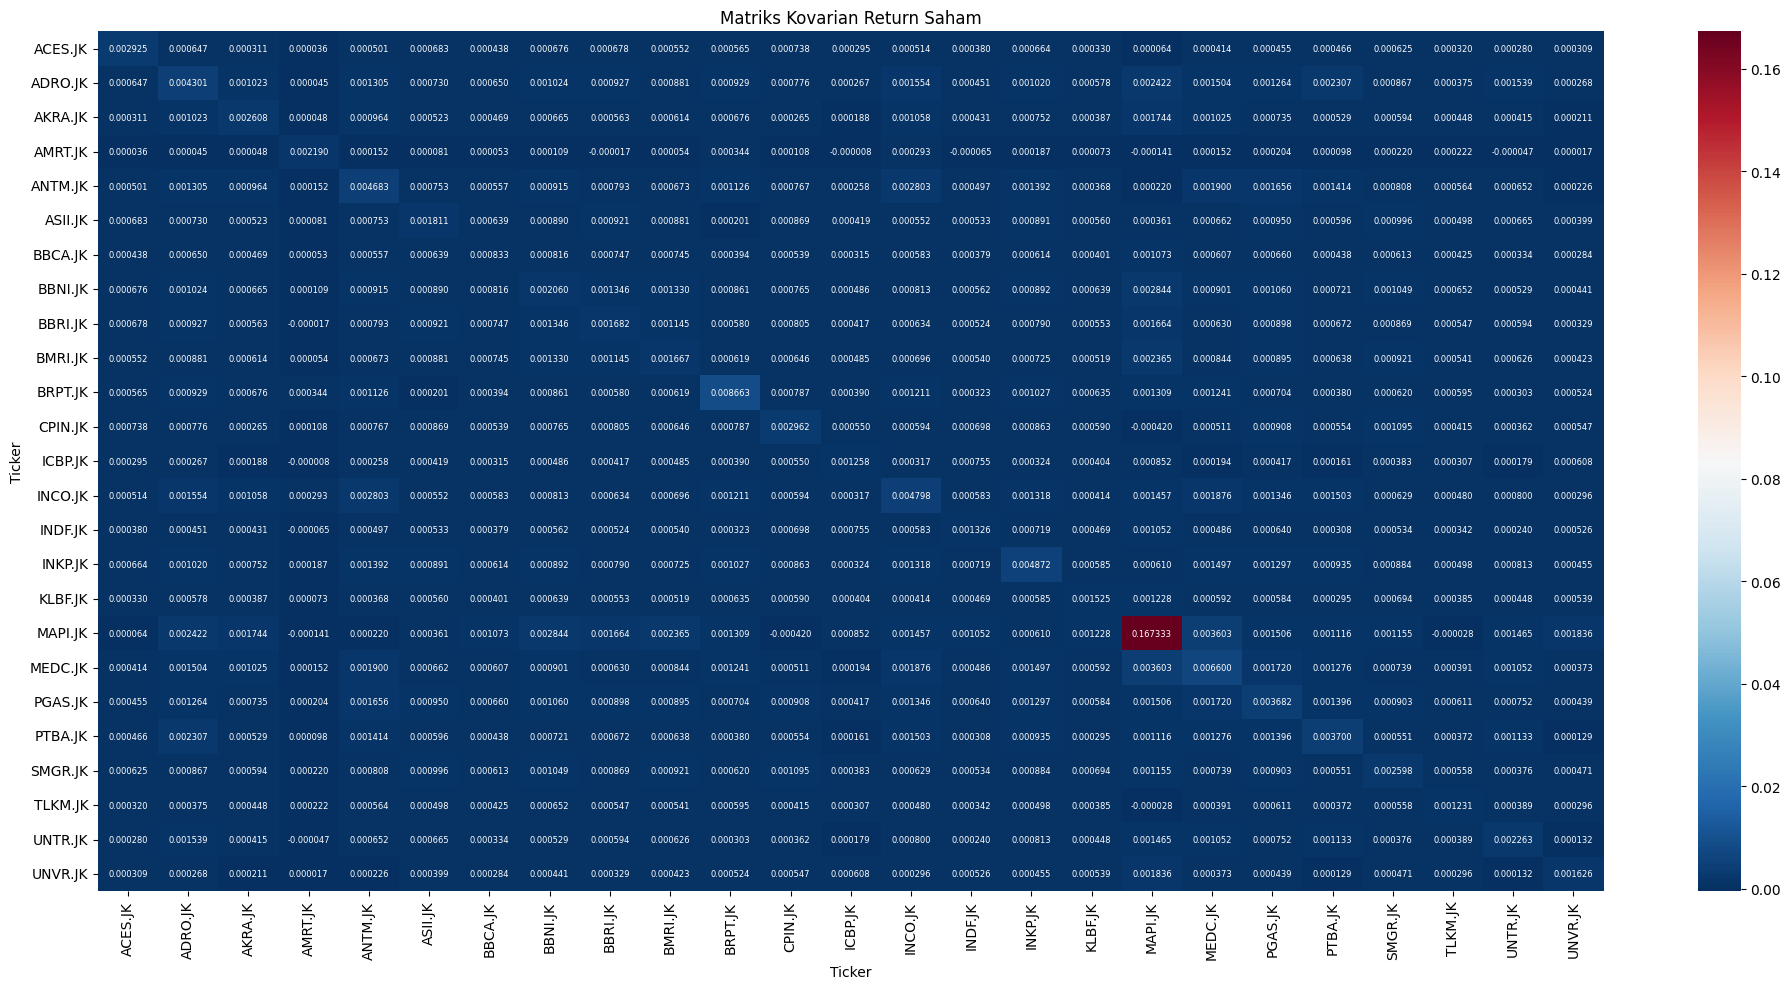

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
sns.heatmap(cov_stock,
            annot=True,  # Menampilkan nilai
            fmt=".6f",   # Format nilai dengan 6 desimal
            cmap="RdBu_r",annot_kws={"size": 6}
            )  # Colormap merah-putih-biru

plt.title("Matriks Kovarian Return Saham")
plt.tight_layout()
plt.show()

##PORTOFOLIO

### Return Portofolio

Rumus Return Portofolio:

$$
R_p = \sum_{i=1}^{n} w_i \cdot R_i
$$

di mana:
- $R_p $ = **Return portofolio**
- $w_i $ = **Bobot** atau proporsi investasi dalam aset $i$
- $R_i $ = **Return** aset $i$
- $ n $  = **Jumlah aset** dalam portofolio


In [13]:
weights = np.array([1/25] * 25)  # bobot sama rata
weights
portfolio_weekly_return = return_stock.dropna().dot(weights)
portfolio_weekly_return.name = "Portofolio Return"
portfolio_weekly_return = portfolio_weekly_return.to_frame()
portfolio_weekly_return

,Portofolio Return
2014-11-10,0.016665
2014-11-17,0.014693
2014-11-24,0.010862
2014-12-01,0.003062
2014-12-08,-0.015680
...,...
2024-09-30,-0.009926
2024-10-07,0.002251
2024-10-14,0.019782
2024-10-21,-0.016686


###Expected Return Portofolio

In [14]:
expected_return_portfolio = portfolio_weekly_return.mean().values[0]
print("Expected Return Portofolio (Mingguan):", round(expected_return_portfolio, 4))
expected_annual_return = portfolio_weekly_return.mean().values[0] * 52
print("Expected Return Portoflio (Tahunan):", round(expected_annual_return, 4))

Expected Return Portofolio (Mingguan): 0.0037
Expected Return Portoflio (Tahunan): 0.1913


### Resiko Portofolio

Rumus Return Portofolio:

$$
\sigma_p = \sqrt{w^T.V.w}
$$

di mana:
- $\sigma_p $ = **Resiko Portofolio**
- $V$ = Matriks Covarian
- $w$ = Bobot


In [17]:
portfolio_variance = np.sqrt(np.dot(weights.T, np.dot(cov_stock, weights)))
portfolio_std_dev = np.sqrt(portfolio_variance)
print("Portfolio Variance:", round(portfolio_variance, 4))
print("Portfolio Standard Deviation:", round(portfolio_std_dev, 4))

Portfolio Variance: 0.0322
Portfolio Standard Deviation: 0.1794


In [18]:
risk_portfolio = portfolio_weekly_return.std().values[0]
print("Risk Portofolio (Mingguan):", round(risk_portfolio, 4))
risk_annual = portfolio_weekly_return.std().values[0] * np.sqrt(52)
print("Risk Portfolio (Tahunan):", round(risk_annual, 4))


Risk Portofolio (Mingguan): 0.0322
Risk Portfolio (Tahunan): 0.2321


In [19]:
risk_free_rate = 0.0665
sharpe_ratio = (expected_annual_return - risk_free_rate) / risk_annual
print("Sharpe Ratio:", round(sharpe_ratio, 4))


Sharpe Ratio: 0.5379


#Testing Kode

**Min ($X_1 ^2 + X_2 ^2 + X_3 ^3$)**

**Dengan Constraint** $X_1 + X_2 + X_3 \geq 1 $

In [7]:
import time

class ImprovedPSOFixedW:
    def __init__(self, num_particles=None, max_iter=1000, dim=5, w=0.7):
        if num_particles is None:
            num_particles = max(30, dim * 15)

        self.num_particles = num_particles
        self.max_iter = max_iter
        self.dim = dim
        self.w = w  # Inertia weight tetap

        self.c1 = 2.0
        self.c2 = 2.0

        self.positions = np.random.uniform(0, 1, (num_particles, dim))
        self.velocities = np.random.uniform(-0.1, 0.1, (num_particles, dim))

        for i in range(num_particles):
            s = np.sum(self.positions[i])
            self.positions[i] = self.positions[i] / s if s > 0 else np.ones(dim)/dim

        self.personal_best_positions = self.positions.copy()
        self.personal_best_scores = np.array([self.fitness(p) for p in self.positions])

        best_idx = np.argmin(self.personal_best_scores)
        self.global_best_position = self.personal_best_positions[best_idx].copy()
        self.global_best_score = self.personal_best_scores[best_idx]

        self.history = []
        self.best_position_history = []

    def fitness(self, x):
        objective = np.sum(x**2)
        const = np.sum(x)
        penalty = 0
        if const < 1:
            penalty += 1 - const
        return objective + penalty

    def repair_solution(self, x):
        x = np.maximum(x, 0)
        s = np.sum(x)
        x = x / s if s > 0 else np.ones(self.dim)/self.dim
        x = np.clip(x, 0, 1)
        s = np.sum(x)
        return x / s if s > 0 else np.ones(self.dim)/self.dim

    def optimize(self, verbose=True):
        if verbose:
            print(f"Running PSO with fixed inertia weight w = {self.w}")

        for iter in range(self.max_iter):
            for i in range(self.num_particles):
                self.positions[i] = self.repair_solution(self.positions[i])
                fit = self.fitness(self.positions[i])

                if fit < self.personal_best_scores[i]:
                    self.personal_best_scores[i] = fit
                    self.personal_best_positions[i] = self.positions[i].copy()

                    if fit < self.global_best_score:
                        self.global_best_score = fit
                        self.global_best_position = self.positions[i].copy()

            for i in range(self.num_particles):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                cognitive = self.c1 * r1 * (self.personal_best_positions[i] - self.positions[i])
                social = self.c2 * r2 * (self.global_best_position - self.positions[i])
                self.velocities[i] = self.w * self.velocities[i] + cognitive + social

                v_max = 0.2
                self.velocities[i] = np.clip(self.velocities[i], -v_max, v_max)
                self.positions[i] += self.velocities[i]

            self.history.append(self.global_best_score)
            self.best_position_history.append(self.global_best_position.copy())

            if verbose and (iter + 1) % max(100, self.max_iter // 10) == 0:
                print(f"Iter {iter+1:4d} | Best Fitness: {self.global_best_score:.8f} | ∑x = {np.sum(self.global_best_position):.6f}")

        return self.global_best_position, self.global_best_score

    def plot_convergence(self):
        plt.figure(figsize=(10, 5))
        plt.semilogy(self.history)
        plt.title("Convergence Plot (Log Scale)")
        plt.xlabel("Iterasi")
        plt.ylabel("Fitness Terbaik")
        plt.grid(True)
        plt.show()

    def plot_dimension_convergence(self):
        position_array = np.array(self.best_position_history)
        plt.figure(figsize=(12, 6))
        for d in range(min(self.dim, 10)):  # Only plot first 10 dimensions
            plt.plot(position_array[:, d], label=f'x{d+1}', alpha=0.8)

        # Add horizontal line at 1/dim (optimal value)
        plt.axhline(y=1/self.dim, color='red', linestyle='--', alpha=0.7,
                   label=f'Optimal (1/{self.dim} = {1/self.dim:.3f})')

        plt.title('Konvergensi per Dimensi')
        plt.xlabel('Iterasi')
        plt.ylabel('Nilai Posisi')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_best_position_bar(self):
        plt.figure(figsize=(max(8, self.dim), 6))
        dim_labels = [f'x{i+1}' for i in range(self.dim)]
        bars = plt.bar(dim_labels, self.global_best_position, alpha=0.7)

        # Add horizontal line at optimal value
        optimal_val = 1/self.dim
        plt.axhline(y=optimal_val, color='red', linestyle='--', alpha=0.7,
                   label=f'Optimal = {optimal_val:.3f}')

        plt.title(f'Posisi Terbaik per Variabel (dim={self.dim})')
        plt.xlabel('Variabel')
        plt.ylabel('Nilai Posisi')
        plt.legend()

        # Add value labels on bars if not too many
        if self.dim <= 20:
            for bar, val in zip(bars, self.global_best_position):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)

        plt.xticks(rotation=45 if self.dim > 10 else 0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def print_analysis(self):
        """Print detailed analysis of results"""
        print("\n" + "="*50)
        print("ANALISIS HASIL PSO")
        print("="*50)
        print(f"Dimensi problem: {self.dim}")
        print(f"Jumlah partikel: {self.num_particles}")
        print(f"Maksimum iterasi: {self.max_iter}")
        print("-"*50)
        print(f"Fitness terbaik: {self.global_best_score:.8f}")
        print(f"Sum constraint: {np.sum(self.global_best_position):.6f}")
        print(f"Target sum: 1.000000")
        print(f"Error sum: {abs(np.sum(self.global_best_position) - 1.0):.6f}")
        print("-"*50)
        print("Posisi terbaik per variabel:")
        optimal_val = 1/self.dim
        for i, val in enumerate(self.global_best_position):
            error = abs(val - optimal_val)
            print(f"  x{i+1:2d} = {val:.6f} (optimal: {optimal_val:.6f}, error: {error:.6f})")
        print("-"*50)
        max_error = max(abs(val - optimal_val) for val in self.global_best_position)
        print(f"Maximum error dari nilai optimal: {max_error:.6f}")
        print(f"Standard deviation: {np.std(self.global_best_position):.6f}")


def run_multiple_experiments(dim=10, num_runs=50, max_iter=2000, w=0.7, verbose=True):
    """
    Menjalankan PSO sebanyak num_runs kali dan menganalisis statistik hasilnya
    """
    print(f"\n{'='*60}")
    print(f"MENJALANKAN {num_runs} EKSPERIMEN PSO")
    print(f"Dimensi: {dim}, Max Iterasi: {max_iter}, Inertia Weight: {w}")
    print(f"{'='*60}")

    results = []
    best_positions = []
    computation_times = []

    for run in range(num_runs):
        if verbose:
            print(f"\nRun {run+1}/{num_runs}")

        start_time = time.time()

        # Buat instance PSO baru untuk setiap run
        pso = ImprovedPSOFixedW(max_iter=max_iter, dim=dim, w=w)
        best_pos, best_score = pso.optimize(verbose=False)

        end_time = time.time()

        results.append(best_score)
        best_positions.append(best_pos)
        computation_times.append(end_time - start_time)

        if verbose:
            print(f"  Fitness: {best_score:.8f}, Time: {end_time - start_time:.2f}s")

    # Konversi ke numpy arrays untuk analisis
    results = np.array(results)
    best_positions = np.array(best_positions)
    computation_times = np.array(computation_times)

    # Hitung statistik
    mean_fitness = np.mean(results)
    min_fitness = np.min(results)
    max_fitness = np.max(results)
    std_fitness = np.std(results)
    variance_fitness = np.var(results)
    median_fitness = np.median(results)

    # Temukan run terbaik dan terburuk
    best_run_idx = np.argmin(results)
    worst_run_idx = np.argmax(results)

    # Print hasil analisis statistik
    print(f"\n{'='*60}")
    print("ANALISIS STATISTIK HASIL")
    print(f"{'='*60}")
    print(f"Jumlah eksperimen: {num_runs}")
    print(f"Dimensi problem: {dim}")
    print(f"{'─'*60}")
    print("STATISTIK FITNESS:")
    print(f"  Rata-rata (Mean)    : {mean_fitness:.8f}")
    print(f"  Nilai terendah (Min): {min_fitness:.8f}")
    print(f"  Nilai tertinggi (Max): {max_fitness:.8f}")
    print(f"  Median              : {median_fitness:.8f}")
    print(f"  Standard Deviasi    : {std_fitness:.8f}")
    print(f"  Variansi            : {variance_fitness:.8f}")
    print(f"{'─'*60}")
    print("STATISTIK WAKTU KOMPUTASI:")
    print(f"  Rata-rata waktu     : {np.mean(computation_times):.2f} detik")
    print(f"  Waktu tercepat      : {np.min(computation_times):.2f} detik")
    print(f"  Waktu terlama       : {np.max(computation_times):.2f} detik")
    print(f"  Total waktu         : {np.sum(computation_times):.2f} detik")

    # Plot

    return {
        'results': results,
        'best_positions': best_positions,
        'statistics': {
            'mean': mean_fitness,
            'min': min_fitness,
            'max': max_fitness,
            'std': std_fitness,
            'variance': variance_fitness,
            'median': median_fitness
        },
        'computation_times': computation_times,
        'best_run_idx': best_run_idx,
        'worst_run_idx': worst_run_idx
    }


In [8]:
if __name__ == "__main__":
    # Jalankan eksperimen
    experiment_results = run_multiple_experiments(
        dim=25,
        num_runs=50,
        max_iter=1000,
        w=0.7,
        verbose=True
    )

    print(f"\n{'='*60}")
    print("EKSPERIMEN SELESAI")
    print(f"{'='*60}")


MENJALANKAN 50 EKSPERIMEN PSO
Dimensi: 25, Max Iterasi: 1000, Inertia Weight: 0.7

Run 1/50
  Fitness: 0.04000246, Time: 21.11s

Run 2/50
  Fitness: 0.04000130, Time: 16.44s

Run 3/50
  Fitness: 0.04000973, Time: 16.43s

Run 4/50
  Fitness: 0.04000120, Time: 17.51s

Run 5/50
  Fitness: 0.04000484, Time: 17.62s

Run 6/50
  Fitness: 0.04000204, Time: 16.46s

Run 7/50
  Fitness: 0.04000380, Time: 17.58s

Run 8/50
  Fitness: 0.04000061, Time: 16.43s

Run 9/50
  Fitness: 0.04000339, Time: 16.48s

Run 10/50
  Fitness: 0.04000451, Time: 17.54s

Run 11/50
  Fitness: 0.04000821, Time: 16.49s

Run 12/50
  Fitness: 0.04000070, Time: 16.88s

Run 13/50
  Fitness: 0.04000287, Time: 17.62s

Run 14/50
  Fitness: 0.04000344, Time: 16.81s

Run 15/50
  Fitness: 0.04000235, Time: 16.54s

Run 16/50
  Fitness: 0.04000401, Time: 17.55s

Run 17/50
  Fitness: 0.04000272, Time: 16.42s

Run 18/50
  Fitness: 0.04000055, Time: 16.50s

Run 19/50
  Fitness: 0.04000369, Time: 17.60s

Run 20/50
  Fitness: 0.04000447,

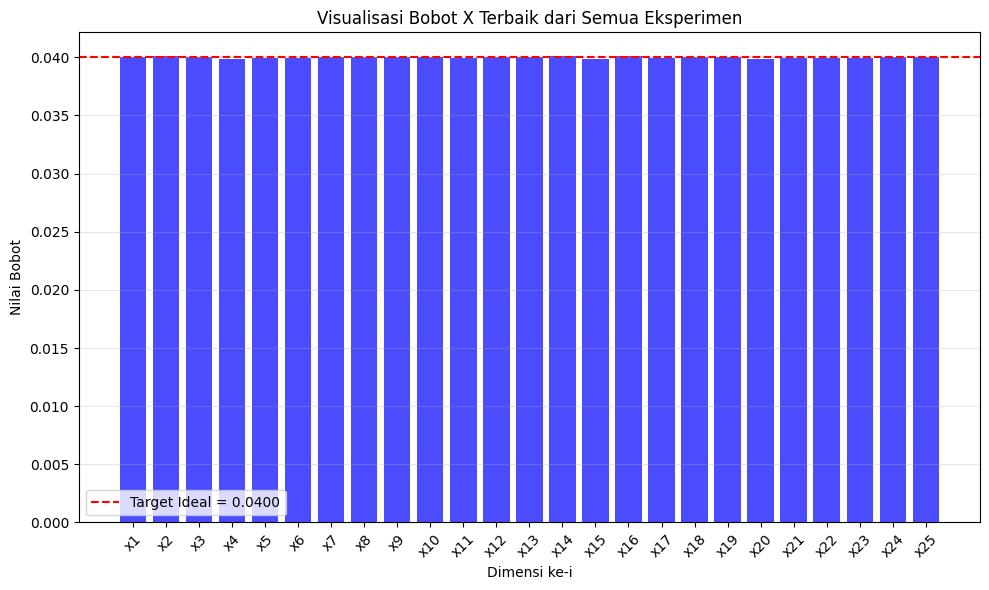

In [14]:
# Ambil data untuk plotting
best_positions = experiment_results["best_positions"]
best_run_idx = experiment_results["best_run_idx"]
dim =25

best_x = best_positions[best_run_idx]

plt.figure(figsize=(10, 6))
plt.bar([f'x{i+1}' for i in range(dim)], best_x, alpha=0.7, color='blue')
plt.axhline(y=1/dim, color='red', linestyle='--', label=f'Target Ideal = {1/dim:.4f}')
plt.title('Visualisasi Bobot X Terbaik dari Semua Eksperimen')
plt.xlabel('Dimensi ke-i')
plt.ylabel('Nilai Bobot')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
if __name__ == "__main__":


    # Jalankan eksperimen
    experiment_results_05 = run_multiple_experiments(
        dim=25,
        num_runs=50,
        max_iter=1000,
        w=0.5,
        verbose=True
    )

    print(f"\n{'='*60}")
    print("EKSPERIMEN SELESAI")
    print(f"{'='*60}")


MENJALANKAN 50 EKSPERIMEN PSO
Dimensi: 25, Max Iterasi: 1000, Inertia Weight: 0.5

Run 1/50
  Fitness: 0.04000000, Time: 16.56s

Run 2/50
  Fitness: 0.04000000, Time: 19.31s

Run 3/50
  Fitness: 0.04000000, Time: 16.92s

Run 4/50
  Fitness: 0.04000000, Time: 16.78s

Run 5/50
  Fitness: 0.04000000, Time: 17.21s

Run 6/50
  Fitness: 0.04000000, Time: 16.49s

Run 7/50
  Fitness: 0.04000000, Time: 16.73s

Run 8/50
  Fitness: 0.04000000, Time: 17.60s

Run 9/50
  Fitness: 0.04000000, Time: 16.48s

Run 10/50
  Fitness: 0.04000000, Time: 17.60s

Run 11/50
  Fitness: 0.04000000, Time: 16.79s

Run 12/50
  Fitness: 0.04000000, Time: 16.47s

Run 13/50
  Fitness: 0.04000000, Time: 17.36s

Run 14/50
  Fitness: 0.04000000, Time: 16.75s

Run 15/50
  Fitness: 0.04000000, Time: 16.52s

Run 16/50
  Fitness: 0.04000000, Time: 17.41s

Run 17/50
  Fitness: 0.04000000, Time: 16.76s

Run 18/50
  Fitness: 0.04000000, Time: 16.49s

Run 19/50
  Fitness: 0.04000000, Time: 17.47s

Run 20/50
  Fitness: 0.04000000,

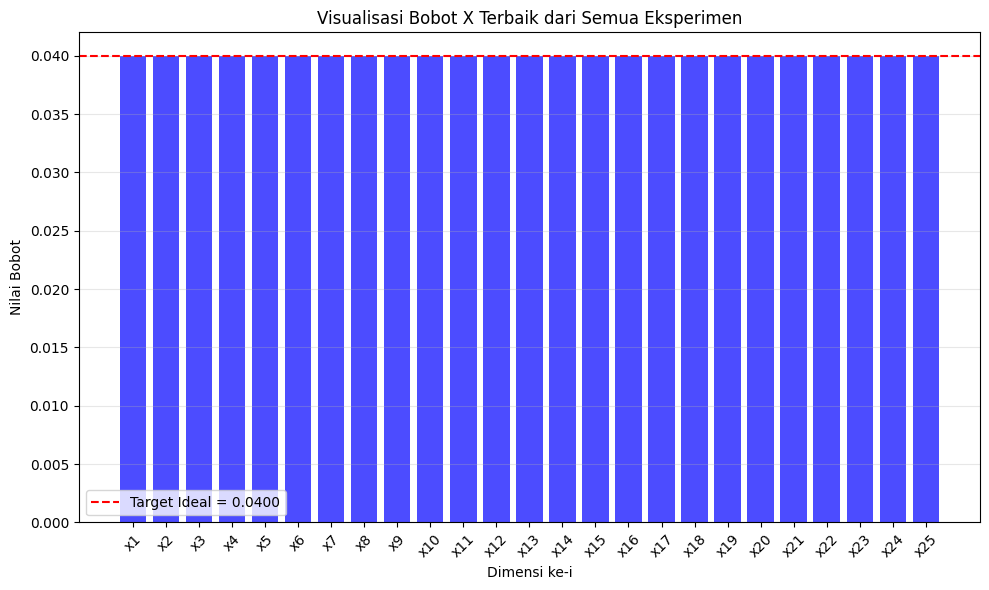

In [16]:
# Ambil data untuk plotting
best_positions = experiment_results_05["best_positions"]
best_run_idx = experiment_results_05["best_run_idx"]
dim =25

best_x = best_positions[best_run_idx]

plt.figure(figsize=(10, 6))
plt.bar([f'x{i+1}' for i in range(dim)], best_x, alpha=0.7, color='blue')
plt.axhline(y=1/dim, color='red', linestyle='--', label=f'Target Ideal = {1/dim:.4f}')
plt.title('Visualisasi Bobot X Terbaik dari Semua Eksperimen')
plt.xlabel('Dimensi ke-i')
plt.ylabel('Nilai Bobot')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#Implementasi Model

Masalah Optimasi -> Meminimunkan Resiko  
$$\min_{w} \frac{1}{2} w^T V w $$
Constraint ->   
$$w^T 1 = 1$$
$$w^T 𝜇 \geq 𝜇_p^*$$
$$w^T \theta \leq θ_p^*$$

$$
v_i^{t+1} = \omega v_i^t + c_1 r_1 \left( p_{best_i}^t - x_i^t \right) + c_2 r_2 \left( g_{best} - x_i^t \right)
$$

**Keterangan:**

- $p_{best_i}^t$ = posisi terbaik pribadi partikel *i*  
- $g_{best}$ = posisi terbaik global  
- $x_i^t$ = posisi terbaik partikel *i* pada iterasi ke-*t*  
- $\omega$ = faktor inersia  
- $c$ = koefisien akselerasi  
- $r$ = bilangan acak dengan distribusi *uniform* antara 0 dan 1

##TANPA ESG

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

class PortfolioOptimizationPSO:
    """
    Optimisasi Portofolio Tanpa Mempertimbangkan ESG
    Single Objective: Minimasi Risiko dengan return sebagai constraints
    """

    def __init__(self, mu, cov, theta=None, stock_names=None,
                 mu_p_star=0.002, theta_p_star=None,
                 max_iter=1000, num_particles=None, objective='risk'):


        self.mu = mu
        self.cov = cov
        self.theta = theta if theta is not None else None
        self.stock_names = stock_names if stock_names is not None else [f'Asset_{i+1}' for i in range(len(self.mu))]

        # Portfolio parameters
        self.mu_p_star = mu_p_star  # Target Return
        self.theta_p_star = theta_p_star  # Target nilai ESG
        self.objective = "risk"

        self.dim = len(self.mu)

        # PSO parameters
        if num_particles is None:
            num_particles = max(30, self.dim * 15)

        self.num_particles = num_particles
        self.max_iter = max_iter
        self.c1 = 2.0         # Cognitive coefficient
        self.c2 = 2.0         # Social coefficient

        # Inisialisasi partikel
        self._initialize_particles()

        self.history = []
        self.best_position_history = []
        self.return_history = []
        self.risk_history = []
        self.esg_history = [] if self.theta is not None else None

    def _initialize_particles(self):
        print(f"Initializing PSO with {self.num_particles} particles for {self.dim} assets")

        # Inisialisasi posisi partikel
        self.positions = np.random.uniform(0, 1, (self.num_particles, self.dim))
        # Inisialisasi kecepatan partikel
        self.velocities = np.random.uniform(0, 1, (self.num_particles, self.dim))

        for i in range(self.num_particles):
            self.positions[i] = self._repair_solution(self.positions[i])

        # Inisialisasi personal bests
        self.personal_best_positions = self.positions.copy()
        self.personal_best_scores = np.array([self.fitness(p) for p in self.positions])

        # Inisialisasi global best
        best_idx = np.argmin(self.personal_best_scores)
        self.global_best_position = self.personal_best_positions[best_idx].copy()
        self.global_best_score = self.personal_best_scores[best_idx]

    def _repair_solution(self, position):
        position = np.maximum(position, 0)

        sum_pos = np.sum(position)
        if sum_pos > 0:
            position = position / sum_pos
        else:
            position = np.ones(self.dim) / self.dim

        position = np.clip(position, 0, 1)

        sum_pos = np.sum(position)
        if sum_pos > 0:
            position = position / sum_pos

        return position

    def fitness(self, weights):
        """Enhanced fitness function with multiple objectives"""
        weights = self._repair_solution(weights)

        port_return = np.dot(weights.T, self.mu)
        port_variance = 0.5*np.dot(weights.T, np.dot(self.cov, weights))
        port_esg = np.dot(weights.T, self.theta)

        objective = port_variance  # Minimasi Resiko
        # Penalty untuk constraints
        penalty = 0

        # Return constraint
        if port_return < self.mu_p_star:
            penalty += (self.mu_p_star - port_return)

        return objective + penalty

    def optimize(self):
        """Main optimization loop"""
        print(f"Starting Enhanced Portfolio PSO optimization")
        print(f"Objective: {self.objective.capitalize()}")
        print(f"Assets: {self.dim}, Particles: {self.num_particles}, Iterations: {self.max_iter}")
        print(f"Target Return: {self.mu_p_star*100:.2f}%")
        print(f"Target ESG: ≤ {self.theta_p_star}")
        print("-" * 60)

        for iteration in range(self.max_iter):
            current_w = 0.5

            # perbarui nilai fitness dan personal bests
            for i in range(self.num_particles):
                self.positions[i] = self._repair_solution(self.positions[i])

                current_fitness = self.fitness(self.positions[i])

                if current_fitness < self.personal_best_scores[i]:
                    self.personal_best_scores[i] = current_fitness
                    self.personal_best_positions[i] = self.positions[i].copy()
                    if current_fitness < self.global_best_score:
                        self.global_best_score = current_fitness
                        self.global_best_position = self.positions[i].copy()

            # Perbarui kecepatan dan posisi
            for i in range(self.num_particles):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                cognitive = self.c1 * r1 * (self.personal_best_positions[i] - self.positions[i])
                social = self.c2 * r2 * (self.global_best_position - self.positions[i])

                self.velocities[i] = current_w * self.velocities[i] + cognitive + social

                v_max = 0.2
                self.velocities[i] = np.clip(self.velocities[i], -v_max, v_max)

                self.positions[i] += self.velocities[i]

            self._update_history()

            if (iteration + 1) % max(50, self.max_iter // 20) == 0:
                self._print_progress(iteration + 1, current_w)

        self._calculate_final_metrics()
        print("\nOptimization completed!")

        return {
          "weights": self.optimal_weights,
          "expected_return": self.optimal_return,
          "volatility": self.optimal_volatility,
          "sharpe_ratio": self.optimal_sharpe,
          "esg_score": getattr(self, "optimal_esg", None),
          "objective_value": self.global_best_score
        }

    def _update_history(self):
        self.history.append(self.global_best_score)
        self.best_position_history.append(self.global_best_position.copy())

        # Portfolio metrics
        port_return = np.dot(self.global_best_position, self.mu)
        port_risk = np.sqrt(np.dot(self.global_best_position, np.dot(self.cov, self.global_best_position)))

        self.return_history.append(port_return)
        self.risk_history.append(port_risk)

        if self.theta is not None:
            port_esg = np.dot(self.global_best_position, self.theta)
            self.esg_history.append(port_esg)

    def _print_progress(self, iteration, inertia_weight):
        port_return = np.dot(self.global_best_position, self.mu)
        port_risk = np.sqrt(np.dot(self.global_best_position, np.dot(self.cov, self.global_best_position)))

        progress_str = f"Iter {iteration:4d}/{self.max_iter} | "
        progress_str += f"Fitness: {self.global_best_score:.6f} | "
        progress_str += f"Return: {port_return*100:5.2f}% | "
        progress_str += f"Risk: {port_risk*100:5.2f}% | "


        if self.theta is not None:
            port_esg = np.dot(self.global_best_position, self.theta)
            progress_str += f" | ESG: {port_esg:.2f}"

        print(progress_str)

    def _calculate_final_metrics(self):
        self.optimal_weights = self.global_best_position
        self.optimal_return = np.dot(self.optimal_weights, self.mu)
        self.optimal_variance = np.dot(self.optimal_weights, np.dot(self.cov, self.optimal_weights))
        self.optimal_volatility = np.sqrt(self.optimal_variance)
        self.optimal_sharpe = ((self.optimal_return*52) - 0.0665 ) / (self.optimal_volatility*np.sqrt(52))

        if self.theta is not None:
            self.optimal_esg = np.dot(self.optimal_weights, self.theta)

    def print_results(self):
        print("\n" + "="*70)
        print("ENHANCED PORTFOLIO OPTIMIZATION RESULTS")
        print("="*70)
        print(f"Optimization Objective: {self.objective.capitalize()}")
        print(f"Number of Assets: {self.dim}")
        print(f"PSO Parameters: {self.num_particles} particles, {self.max_iter} iterations")
        print("\nOptimal Portfolio Metrics:")
        print("-"*70)
        print(f"Expected Return (Weekly):           {self.optimal_return*100:6.2f}% (Target: ≥{self.mu_p_star*100:6.2f}%)")
        print(f"Expected Return (Annual):           {self.optimal_return*52*100:6.2f}%")
        print(f"Optimal Portfolio Risk (Weekly):    {self.optimal_volatility*100:6.2f}% (Portfolio Risk: {risk_portfolio*100:6.2f}%)")
        print(f"Optimal Portfolio Risk (Annual):    {self.optimal_volatility*np.sqrt(52)*100:6.2f}%")
        print(f"Sharpe Ratio:               {self.optimal_sharpe:.4f}")

        if hasattr(self, 'optimal_esg'):
            target_str = f"≤{self.theta_p_star}" if self.theta_p_star else "N/A"
            print(f"ESG Score:                  {self.optimal_esg:6.2f} (Target: {target_str})")

        print("\nOptimal Asset Allocation:")
        print("-"*70)

        # Sort by weight for better display
        sorted_indices = np.argsort(self.optimal_weights)[::-1]

        for idx in sorted_indices:
            weight = self.optimal_weights[idx] * 100
            if weight > 0.01:  # Only show weights > 0.01%
                asset_info = f"{self.stock_names[idx]:<12}: {weight:6.2f}%"
                if self.theta is not None:
                    asset_info += f"   (ESG: {self.theta[idx]:5.2f})"
                print(asset_info)

        # Constraint satisfaction
        print("\Constraint Status:")
        print("-"*70)
        return_satisfied = "✅" if self.optimal_return >= self.mu_p_star else "❌"
        print(f"Return Constraint: {return_satisfied}")

        if hasattr(self, 'optimal_esg') and self.theta_p_star is not None:
            esg_satisfied = "✅" if int(self.optimal_esg) <= self.theta_p_star else "❌"
            print(f"ESG Constraint:    {esg_satisfied}")

        print(f"Budget Constraint: ✅ (Sum = {np.sum(self.optimal_weights):.6f})")
        print("="*70)

    def plot_convergence(self):
        """Plot convergence curves"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Fitness convergence
        axes[0,0].semilogy(self.history)
        axes[0,0].set_title('Fitness Convergence (Log Scale)')
        axes[0,0].set_xlabel('Iteration')
        axes[0,0].set_ylabel('Fitness Value (Log)')
        axes[0,0].grid(True, alpha=0.3)

        # Return convergence
        axes[0,1].plot(np.array(self.return_history) * 100)
        axes[0,1].axhline(y=self.mu_p_star*100, color='red', linestyle='--',
                         label=f'Target Return ({self.mu_p_star*100:.2f}%)')
        axes[0,1].set_title('Portfolio Return Convergence')
        axes[0,1].set_xlabel('Iteration')
        axes[0,1].set_ylabel('Return (%)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        # Risk convergence
        axes[1,0].plot(np.array(self.risk_history) * 100)
        axes[1,0].axhline(y=risk_portfolio*100, color='red', linestyle='--',
                         label=f'Target Return ({risk_portfolio*100:.2f}%)')
        axes[1,0].set_title('Portfolio Risk Convergence')
        axes[1,0].set_xlabel('Iteration')
        axes[1,0].set_ylabel('Risk (%)')
        axes[1,0].grid(True, alpha=0.3)

        # ESG convergence (if available)
        if self.esg_history:
            axes[1,1].plot(self.esg_history)
            if self.theta_p_star:
                axes[1,1].axhline(y=self.theta_p_star, color='red', linestyle='--',
                                 label=f'Target ESG (≤{self.theta_p_star})')
                axes[1,1].legend()
            axes[1,1].set_title('ESG Score Convergence')
            axes[1,1].set_xlabel('Iteration')
            axes[1,1].set_ylabel('ESG Score')
            axes[1,1].grid(True, alpha=0.3)
        else:
            # Plot Sharpe ratio instead
            sharpe_history = np.array(self.return_history) / np.array(self.risk_history)
            axes[1,1].plot(sharpe_history)
            axes[1,1].set_title('Sharpe Ratio Convergence')
            axes[1,1].set_xlabel('Iteration')
            axes[1,1].set_ylabel('Sharpe Ratio')
            axes[1,1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_weights(self):
        """Plot optimal weights distribution"""
        plt.figure(figsize=(12, 8))

      # Tampilkan semua saham
        weights_to_plot = self.optimal_weights * 100
        names_to_plot = self.stock_names

        bars = plt.bar(names_to_plot, weights_to_plot, alpha=0.7, color='steelblue')

        plt.title(f'Optimal Portfolio Weight Without ESG', fontsize=14, fontweight='bold')
        plt.xlabel('Assets', fontsize=12)
        plt.ylabel('Weight (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        for bar, weight in zip(bars, weights_to_plot):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{weight:.1f}%', ha='center', va='bottom', fontweight='bold')

        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()


Optimasi Portfolio PSO tanpa ESG
--------------------------------------------------

Run 1/20
Initializing PSO with 375 particles for 25 assets
Starting Enhanced Portfolio PSO optimization
Objective: Risk
Assets: 25, Particles: 375, Iterations: 1000
Target Return: 0.12%
Target ESG: ≤ None
------------------------------------------------------------
Iter   50/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |  | ESG: 28.32
Iter  100/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |  | ESG: 28.32
Iter  150/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |  | ESG: 28.32
Iter  200/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |  | ESG: 28.32
Iter  250/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |  | ESG: 28.32
Iter  300/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |  | ESG: 28.32
Iter  350/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |  | ESG: 28.32
Iter  400/1000 | Fitness: 0.000212 | Return:  0.27% | Risk:  2.06% |

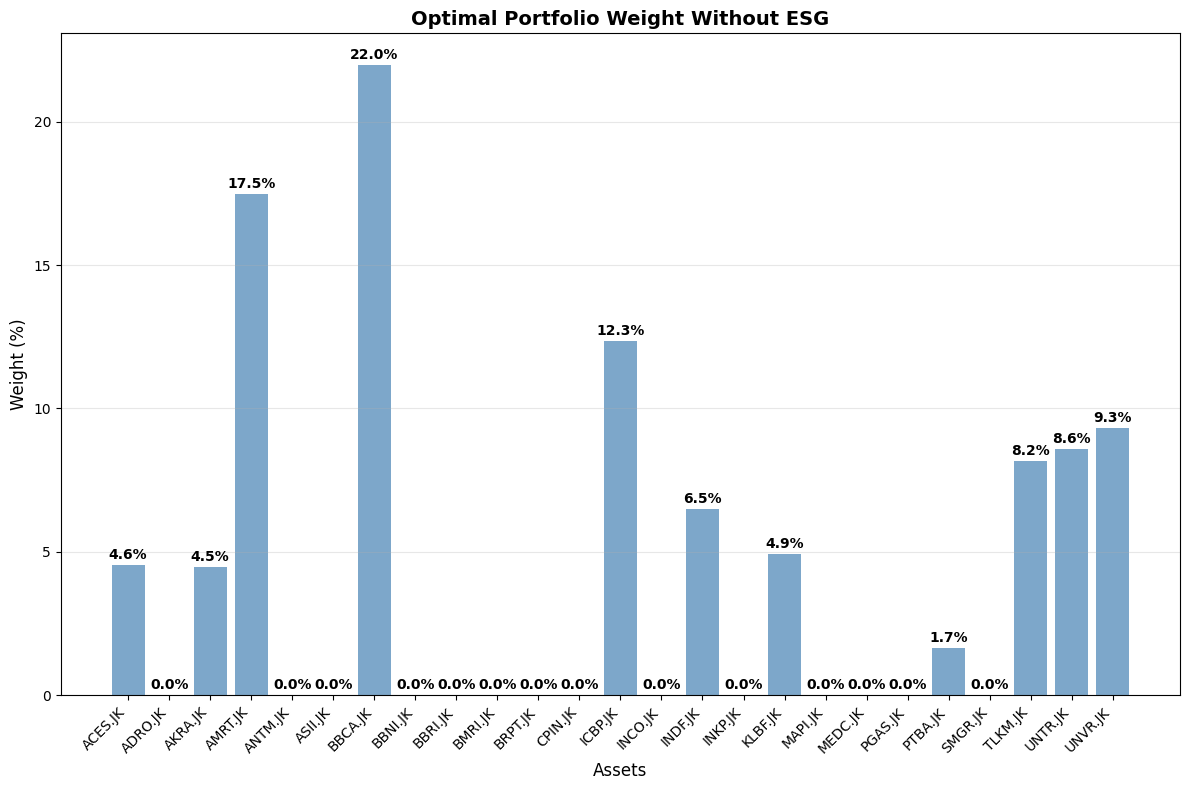

In [ ]:
import time

if __name__ == "__main__":
    print("Optimasi Portfolio PSO tanpa ESG")
    print("-" * 50)

    best_fitness = float('inf')
    best_weights = None
    best_result = None

    fitness_list = []
    waktu_list = []

    for run in range(1, 21):
        print(f"\nRun {run}/20")

        start_time = time.time()


        optimizer = PortfolioOptimizationPSO(
          mu=expected_returns.values,
          cov=cov_stock,
          theta=esg_df['ESG_Score'].values,
          stock_names=esg_df['Ticker'].values,
          mu_p_star=0.0012,   # Target expected return
          max_iter=1000,      # Target ESG
          objective='risk'
      )

        result = optimizer.optimize()
        elapsed = time.time() - start_time
        waktu_list.append(elapsed)
        fitness_list.append(result['objective_value'])

        print(f"Run {run} - Fitness: {result['objective_value']:.8f} | Time: {elapsed:.2f} sec")

        if result['objective_value'] < best_fitness:
            best_fitness = result['objective_value']
            best_weights = result['weights']
            best_result = result
            best_optimizer = optimizer

    # Statistik fitness
    fitness_array = np.array(fitness_list)
    print("\n" + "_"*70)
    print("STATISTIK FITNESS:")
    print(f"Rata-rata (Mean)   : {np.mean(fitness_array):.8f}")
    print(f"Nilai terendah (Min): {np.min(fitness_array):.8f}")
    print(f"Nilai tertinggi (Max): {np.max(fitness_array):.8f}")
    print(f"Median             : {np.median(fitness_array):.8f}")
    print(f"Variansi           : {np.var(fitness_array):.8f}")

    # Statistik waktu
    waktu_array = np.array(waktu_list)
    print("\n" + "_"*70)
    print("STATISTIK WAKTU KOMPUTASI:")
    print(f"Rata-rata waktu    : {np.mean(waktu_array):.2f} detik")
    print(f"Waktu tercepat     : {np.min(waktu_array):.2f} detik")
    print(f"Waktu terlama      : {np.max(waktu_array):.2f} detik")
    print(f"Total waktu        : {np.sum(waktu_array):.2f} detik")

    # Hasil terbaik
    print("\n\n Best Result ")
    print(f"Best Fitness: {best_fitness:.8f}")
    print("Best Weights Allocation:")
    for name, weight in zip(best_optimizer.stock_names, best_weights):
        if weight > 0.001:
            print(f"{name:<12}: {weight*100:.2f}%")

    # visualisasi dari run terbaik
    best_optimizer.print_results()
    # best_optimizer.plot_convergence()
    best_optimizer.plot_weights()


##Dengan ESG


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

dataOptimal = pd.DataFrame()

class PortfolioOptimizationPSOESG:
    """
    Optimasi Portofolio Mempertimbangkan ESG
    Single Objective: Minimasi Risiko dengan Return and ESG sebagai constraints
    """

    def __init__(self, mu, cov, theta=None, stock_names=None,
                 mu_p_star=0.002, theta_p_star=None,
                 max_iter=1000, num_particles=None, objective='risk'):
        self.mu = mu
        self.cov = cov
        self.theta = theta if theta is not None else None
        self.stock_names = stock_names if stock_names is not None else [f'Asset_{i+1}' for i in range(len(self.mu))]

        # Portfolio parameters
        self.mu_p_star = mu_p_star
        self.theta_p_star = theta_p_star
        self.objective = "risk"

        #Dimensionalitas masalah
        self.dim = len(self.mu)

        # PSO parameters
        if num_particles is None:
            num_particles = max(30, self.dim * 15)

        self.num_particles = num_particles * 2
        self.max_iter = max_iter

        self.c1 = 2.0         # Cognitive coefficient
        self.c2 = 2.0         # Social coefficient

        # Inisialisasi partikel
        self._initialize_particles()

        # History tracking
        self.history = []
        self.best_position_history = []
        self.return_history = []
        self.risk_history = []
        self.esg_history = [] if self.theta is not None else None

    def _initialize_particles(self):
        print(f"Initializing PSO with {self.num_particles} particles for {self.dim} assets")

        # Inisialisasi posisi partikel
        self.positions = np.random.uniform(0, 1, (self.num_particles, self.dim))
        # Inisialisasi kecepatan partikel
        self.velocities = np.random.uniform(0, 1, (self.num_particles, self.dim))

        for i in range(self.num_particles):
            self.positions[i] = self._repair_solution(self.positions[i])

        # Inisialisasi personal bests
        self.personal_best_positions = self.positions.copy()
        self.personal_best_scores = np.array([self.fitness(p) for p in self.positions])

        # Inisialisasi global best
        best_idx = np.argmin(self.personal_best_scores)
        self.global_best_position = self.personal_best_positions[best_idx].copy()
        self.global_best_score = self.personal_best_scores[best_idx]

    def _repair_solution(self, position):
        position = np.maximum(position, 0)

        sum_pos = np.sum(position)
        if sum_pos > 0:
            position = position / sum_pos
        else:

            position = np.ones(self.dim) / self.dim

        position = np.clip(position, 0, 1)

        sum_pos = np.sum(position)
        if sum_pos > 0:
            position = position / sum_pos

        return position

    def fitness(self, weights):
        weights = self._repair_solution(weights)

        port_return = np.dot(weights.T, self.mu)
        port_variance = 0.5*np.dot(weights.T, np.dot(self.cov, weights))
        port_esg = np.dot(weights.T, self.theta)

        objective = port_variance  # Minimasi Resiko


        # Penalty untuk constraints
        penalty = 0

        # Return constraint
        if port_return < self.mu_p_star:
            penalty += (self.mu_p_star - port_return)

        # ESG constraint
        if self.theta is not None:
          if port_esg > self.theta_p_star:
            penalty += (port_esg - self.theta_p_star)

        return objective + penalty


    def optimize(self):
        """Main optimization loop"""
        print(f"Starting Enhanced Portfolio PSO optimization")
        print(f"Objective: {self.objective.capitalize()}")
        print(f"Assets: {self.dim}, Particles: {self.num_particles}, Iterations: {self.max_iter}")
        print(f"Target Return: {self.mu_p_star*100:.2f}%")
        print(f"Target ESG: ≤ {self.theta_p_star}")
        print("-" * 60)

        for iteration in range(self.max_iter):
            current_w = 0.5

            # perbarui fitness dan personal best
            for i in range(self.num_particles):
                self.positions[i] = self._repair_solution(self.positions[i])

                current_fitness = self.fitness(self.positions[i])

                if current_fitness < self.personal_best_scores[i]:
                    self.personal_best_scores[i] = current_fitness
                    self.personal_best_positions[i] = self.positions[i].copy()

                    # Check for global best
                    if current_fitness < self.global_best_score:
                        self.global_best_score = current_fitness
                        self.global_best_position = self.positions[i].copy()

            # Perbarui kecepatan and posisi
            for i in range(self.num_particles):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                cognitive = self.c1 * r1 * (self.personal_best_positions[i] - self.positions[i])
                social = self.c2 * r2 * (self.global_best_position - self.positions[i])

                self.velocities[i] = current_w * self.velocities[i] + cognitive + social

                v_max = 0.2
                self.velocities[i] = np.clip(self.velocities[i], -v_max, v_max)

                self.positions[i] += self.velocities[i]

            self._update_history()

            if (iteration + 1) % max(50, self.max_iter // 20) == 0:
                self._print_progress(iteration + 1, current_w)

        self._calculate_final_metrics()
        print("\nOptimization completed!")

        return {
          "weights": self.optimal_weights,
          "expected_return": self.optimal_return,
          "volatility": self.optimal_volatility,
          "sharpe_ratio": self.optimal_sharpe,
          "esg_score": getattr(self, "optimal_esg", None),
          "objective_value": self.global_best_score
        }

    def _update_history(self):
        """Update optimization history"""
        self.history.append(self.global_best_score)
        self.best_position_history.append(self.global_best_position.copy())

        port_return = np.dot(self.global_best_position, self.mu)
        port_risk = np.sqrt(np.dot(self.global_best_position, np.dot(self.cov, self.global_best_position)))

        self.return_history.append(port_return)
        self.risk_history.append(port_risk)

        if self.theta is not None:
            port_esg = np.dot(self.global_best_position, self.theta)
            self.esg_history.append(port_esg)

    def _print_progress(self, iteration, inertia_weight):
        """Print optimization progress"""
        port_return = np.dot(self.global_best_position, self.mu)
        port_risk = np.sqrt(np.dot(self.global_best_position, np.dot(self.cov, self.global_best_position)))

        progress_str = f"Iter {iteration:4d}/{self.max_iter} | "
        progress_str += f"Fitness: {self.global_best_score:.6f} | "
        progress_str += f"Return: {port_return*100:5.2f}% | "
        progress_str += f"Risk: {port_risk*100:5.2f}% | "

        if self.theta is not None:
            port_esg = np.dot(self.global_best_position, self.theta)
            progress_str += f" | ESG: {port_esg:.2f}"

        print(progress_str)

    def _calculate_final_metrics(self):
        """Calculate final portfolio metrics"""
        self.optimal_weights = self.global_best_position
        self.optimal_return = np.dot(self.optimal_weights, self.mu)
        self.optimal_variance = np.dot(self.optimal_weights, np.dot(self.cov, self.optimal_weights))
        self.optimal_volatility = np.sqrt(self.optimal_variance)
        self.optimal_sharpe = ((self.optimal_return*52) - 0.0665 ) / (self.optimal_volatility*np.sqrt(52))


        if self.theta is not None:
            self.optimal_esg = np.dot(self.optimal_weights, self.theta)

    def print_results(self):
        """Print detailed optimization results"""
        print("\n" + "="*70)
        print("PORTFOLIO OPTIMIZATION RESULTS")
        print("="*70)

        print(f"Optimization Objective: {self.objective.capitalize()}")
        print(f"Number of Assets: {self.dim}")
        print(f"PSO Parameters: {self.num_particles} particles, {self.max_iter} iterations")

        print("\n Optimal Portfolio Metrics:")
        print("-"*70)
        print(f"Expected Return (Weekly):   {self.optimal_return*100:6.2f}% (Target: ≥{self.mu_p_star*100:6.2f}%)")
        print(f"Expected Return (Annual):   {self.optimal_return*52*100:6.2f}% (Target: ≥{self.mu_p_star*52*100:6.2f}%)")
        print(f"Optimal Portfolio Risk (Weekly):    {self.optimal_volatility*100:6.2f}% (Portfolio Risk: {risk_portfolio*100:6.2f}%)")
        print(f"Optimal Portfolio Risk (Annual):    {self.optimal_volatility*np.sqrt(52)*100:6.2f}% (Portfolio Risk: {risk_portfolio*np.sqrt(52)*100:6.2f}%)")
        print(f"Sharpe Ratio:               {self.optimal_sharpe:.4f}")

        if hasattr(self, 'optimal_esg'):
            target_str = f"≤{self.theta_p_star}" if self.theta_p_star else "N/A"
            print(f"ESG Score:                  {self.optimal_esg:6.2f} (Target: {target_str})")

        print("\nOptimal Asset Allocation:")
        print("-"*70)

        sorted_indices = np.argsort(self.optimal_weights)[::-1]

        for idx in sorted_indices:
            weight = self.optimal_weights[idx] * 100
            if weight > 0.01:
                asset_info = f"{self.stock_names[idx]:<12}: {weight:6.2f}%"
                if self.theta is not None:
                    asset_info += f"   (ESG: {self.theta[idx]:5.2f})"
                print(asset_info)

        print("\nConstraint Status:")
        print("-"*70)
        return_satisfied = "✅" if self.optimal_return >= self.mu_p_star else "❌"
        print(f"Return Constraint: {return_satisfied}")

        if hasattr(self, 'optimal_esg') and self.theta_p_star is not None:
            esg_satisfied = "✅" if int(self.optimal_esg) <= self.theta_p_star else "❌"
            print(f"ESG Constraint:    {esg_satisfied}")

        print(f"Budget Constraint: ✅ (Sum = {np.sum(self.optimal_weights):.6f})")
        print("="*70)

    def plot_convergence(self):
        """Plot convergence curves"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))


        axes[0,0].semilogy(self.history)
        axes[0,0].set_title('Fitness Convergence (Log Scale)')
        axes[0,0].set_xlabel('Iteration')
        axes[0,0].set_ylabel('Fitness Value (Log)')
        axes[0,0].grid(True, alpha=0.3)

        axes[0,1].plot(np.array(self.return_history) * 100)
        axes[0,1].axhline(y=self.mu_p_star*100, color='red', linestyle='--',
                         label=f'Target Return ({self.mu_p_star*100:.2f}%)')
        axes[0,1].set_title('Portfolio Return Convergence')
        axes[0,1].set_xlabel('Iteration')
        axes[0,1].set_ylabel('Return (%)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        axes[1,0].plot(np.array(self.risk_history) * 100)
        axes[1,0].axhline(y=risk_portfolio*100, color='red', linestyle='--',
                         label=f'Target Return ({risk_portfolio*100:.2f}%)')
        axes[1,0].set_title('Portfolio Risk Convergence')
        axes[1,0].set_xlabel('Iteration')
        axes[1,0].set_ylabel('Risk (%)')
        axes[1,0].grid(True, alpha=0.3)
        if self.esg_history:
            axes[1,1].plot(self.esg_history)
            if self.theta_p_star:
                axes[1,1].axhline(y=self.theta_p_star, color='red', linestyle='--',
                                 label=f'Target ESG (≤{self.theta_p_star})')
                axes[1,1].legend()
            axes[1,1].set_title('ESG Score Convergence')
            axes[1,1].set_xlabel('Iteration')
            axes[1,1].set_ylabel('ESG Score')
            axes[1,1].grid(True, alpha=0.3)
        else:
            # Plot Sharpe ratio instead
            sharpe_history = np.array(self.return_history) / np.array(self.risk_history)
            axes[1,1].plot(sharpe_history)
            axes[1,1].set_title('Sharpe Ratio Convergence')
            axes[1,1].set_xlabel('Iteration')
            axes[1,1].set_ylabel('Sharpe Ratio')
            axes[1,1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_weights(self):
        """Plot optimal weights distribution"""
        plt.figure(figsize=(12, 8))

      # Tampilkan semua saham
        weights_to_plot = self.optimal_weights * 100
        names_to_plot = self.stock_names

        bars = plt.bar(names_to_plot, weights_to_plot, alpha=0.7, color='steelblue')

        plt.title(f'Optimal Portfolio Weight ESG = {self.theta_p_star}', fontsize=14, fontweight='bold')
        plt.xlabel('Assets', fontsize=12)
        plt.ylabel('Weight (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')

        for bar, weight in zip(bars, weights_to_plot):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{weight:.1f}%', ha='center', va='bottom', fontweight='bold')

        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

Optimasi Portfolio PSO dengan ESG 
--------------------------------------------------

Run 1/20
Initializing PSO with 750 particles for 25 assets
Starting Enhanced Portfolio PSO optimization
Objective: Risk
Assets: 25, Particles: 750, Iterations: 1000
Target Return: 0.12%
Target ESG: ≤ 20
------------------------------------------------------------
Iter   50/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.53% |  | ESG: 20.00
Iter  100/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.52% |  | ESG: 20.00
Iter  150/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.52% |  | ESG: 20.00
Iter  200/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.52% |  | ESG: 20.00
Iter  250/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.52% |  | ESG: 20.00
Iter  300/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.52% |  | ESG: 20.00
Iter  350/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.52% |  | ESG: 20.00
Iter  400/1000 | Fitness: 0.000319 | Return:  0.19% | Risk:  2.52% |

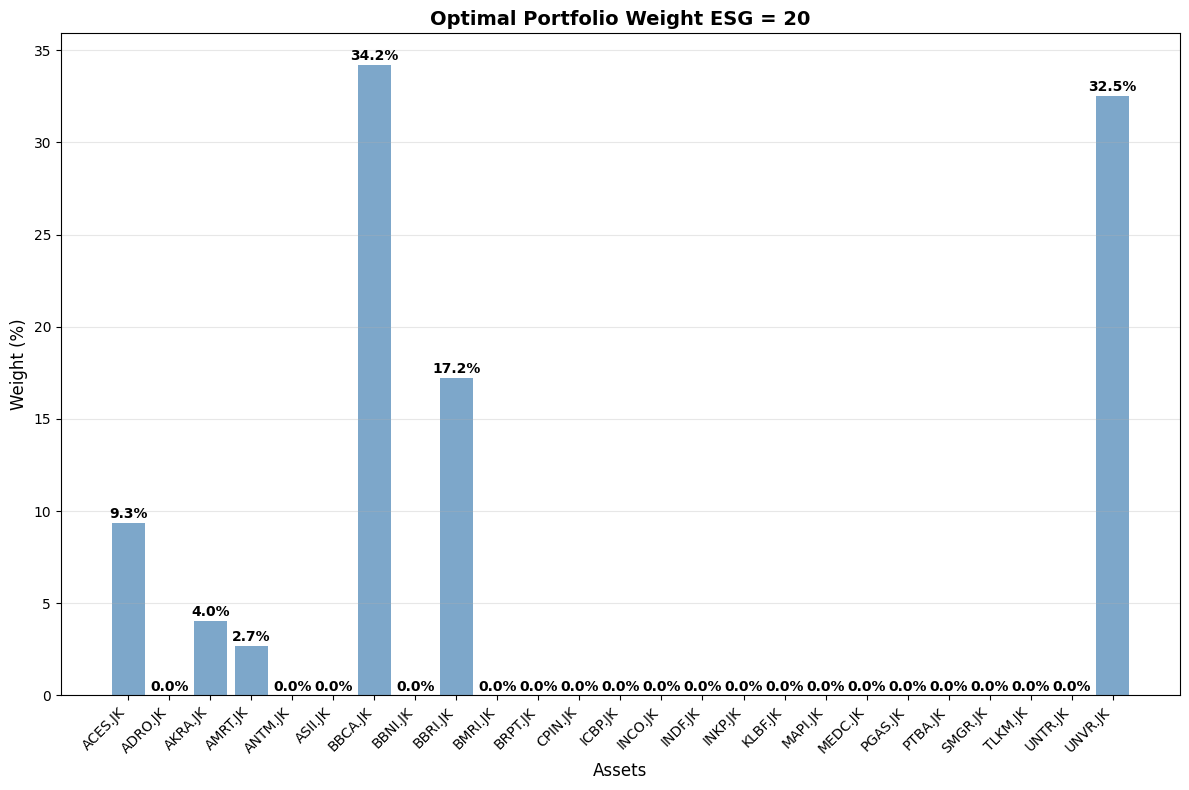

In [ ]:
import time

if __name__ == "__main__":
    print("Optimasi Portfolio PSO dengan ESG ")
    print("-" * 50)

    best_fitnessESG = float('inf')
    best_weightsESG = None
    best_resultESG = None

    fitness_list = []
    waktu_list = []

    for run in range(1, 21):
        print(f"\nRun {run}/20")

        start_time = time.time()

        optimizer = PortfolioOptimizationPSOESG(
            mu=expected_returns.values,
            cov=cov_stock,
            theta=esg_df['ESG_Score'].values,
            stock_names=esg_df['Ticker'].values,
            mu_p_star=0.0012,    # Target expected return
            theta_p_star=20,     # Target ESG
            max_iter=1000,
            objective='risk'
        )

        resultESG = optimizer.optimize()
        elapsed = time.time() - start_time
        waktu_list.append(elapsed)
        fitness_list.append(resultESG['objective_value'])

        print(f"Run {run} - Fitness: {resultESG['objective_value']:.8f} | Time: {elapsed:.2f} sec")

        if resultESG['objective_value'] < best_fitnessESG:
            best_fitnessESG = resultESG['objective_value']
            best_weightsESG = resultESG['weights']
            best_resultESG = resultESG
            best_optimizerESG = optimizer

    # Statistik fitness
    fitness_array = np.array(fitness_list)
    print("\n" + "_"*70)
    print("STATISTIK FITNESS:")
    print(f"Rata-rata (Mean)   : {np.mean(fitness_array):.8f}")
    print(f"Nilai terendah (Min): {np.min(fitness_array):.8f}")
    print(f"Nilai tertinggi (Max): {np.max(fitness_array):.8f}")
    print(f"Median             : {np.median(fitness_array):.8f}")
    print(f"Variansi           : {np.var(fitness_array):.8f}")

    # Statistik waktu
    waktu_array = np.array(waktu_list)
    print("\n" + "_"*70)
    print("STATISTIK WAKTU KOMPUTASI:")
    print(f"Rata-rata waktu    : {np.mean(waktu_array):.2f} detik")
    print(f"Waktu tercepat     : {np.min(waktu_array):.2f} detik")
    print(f"Waktu terlama      : {np.max(waktu_array):.2f} detik")
    print(f"Total waktu        : {np.sum(waktu_array):.2f} detik")

    # Hasil terbaik
    print("\n\n Best Result ")
    print(f"Best Fitness: {best_fitnessESG:.8f}")
    print("Best Weights Allocation:")
    for name, weight in zip(best_optimizerESG.stock_names, best_weightsESG):
        if weight > 0.001:
            print(f"{name:<12}: {weight*100:.2f}%")

    # visualisasi dari run terbaik
    best_optimizerESG.print_results()
    # best_optimizer.plot_convergence()
    best_optimizerESG.plot_weights()


#Pengujian


In [ ]:
dataOptimalWESG = result
dataOptimalWESG

{'weights': array([0.04675678, 0.        , 0.04611867, 0.17578898, 0.        ,
        0.        , 0.22470769, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.12267319, 0.        , 0.06671038,
        0.        , 0.04840886, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.08233855, 0.09353363, 0.09296327]),
 'expected_return': np.float64(0.0026255048341337034),
 'volatility': np.float64(0.0203620718364259),
 'sharpe_ratio': np.float64(0.47691089210671317),
 'esg_score': np.float64(28.390706250467254),
 'objective_value': np.float64(0.00020730698473588424)}

In [ ]:
dataOptimal = resultESG
dataOptimal

{'weights': array([0.0962263 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.45591779, 0.        , 0.11928975, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.0192814 , 0.        , 0.30928477]),
 'expected_return': np.float64(0.0019369223317778587),
 'volatility': np.float64(0.02555418414965088),
 'sharpe_ratio': np.float64(0.18570167521677985),
 'esg_score': np.float64(19.999999999959577),
 'objective_value': np.float64(0.0003265081637771341)}

In [ ]:

dataTicker = [
    'ACES.JK', 'ADRO.JK', 'AKRA.JK', "AMRT.JK", "ANTM.JK",
    "ASII.JK", 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', "BMRI.JK",
    'BRPT.JK', 'CPIN.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK',
    'INKP.JK', 'KLBF.JK', 'MAPI.JK', 'MEDC.JK', 'PGAS.JK',
    'PTBA.JK', 'SMGR.JK', 'TLKM.JK', 'UNTR.JK', 'UNVR.JK'

]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# Bobot Portofolio Dengan Mempertimbangkan ESG
dataOptimal_float = list(map(float, dataOptimal['weights']))
weights = dict(zip(dataTicker, dataOptimal_float))
weights
tickers = list(weights.keys())

# Unduh Data Saham
start_date = '2022-01-01'
end_date = '2024-01-01'
# Mengubah string menjadi objek datetime
start_date_obj = datetime.strptime(start_date, '%Y-%m-%d')
end_date_obj = datetime.strptime(end_date, '%Y-%m-%d')

# Mengambil tahun dari objek datetime
tahun_start = start_date_obj.year
tahun_end = end_date_obj.year

data = yf.download(tickers , start=start_date, end=end_date, interval='1wk')['Close']
data = data.dropna()
returns = data.pct_change().dropna()

# Hitung Return Portofolio
portfolio_weights = np.array([weights[t] for t in tickers])
returns_portfolio = returns[tickers] @ portfolio_weights


dataIDX30 = pd.read_csv("Data Historis IDX 30 Weekly.csv", index_col=0, parse_dates=True)
dataIDX30 = dataIDX30['Terakhir'] \
    .astype(str) \
    .str.replace(',', '.', regex=False) \
    .astype(float) \

returnsIDX30 = dataIDX30.pct_change().dropna()

portfolio_cum = (1 + returns_portfolio).cumprod()
idx30_cum = (1 + returnsIDX30).cumprod()



/tmp/ipython-input-64-2640147043.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers , start=start_date, end=end_date, interval='1wk')['Close']
[*********************100%***********************]  25 of 25 completed
/tmp/ipython-input-64-2640147043.py:33: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataIDX30 = pd.read_csv("Data Historis IDX 30 Weekly.csv", index_col=0, parse_dates=True)


/tmp/ipython-input-66-4282145377.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dataWESG = yf.download(tickers, start=start_date, end=end_date, interval='1wk')['Close']
[*********************100%***********************]  25 of 25 completed



📊 Rangkuman Kinerja Portofolio vs ETF IDX30
---------------------------------------------------
                            Expected Return (%)  Risk (%)  Sharpe Ratio  \
Portofolio PSO Without ESG                17.92     10.98          1.03   
Portfolio PSO With ESG                     7.08     13.44          0.03   
IDX 30                                     1.49     13.56         -0.38   

                            ESG Score  
Portofolio PSO Without ESG      28.39  
Portfolio PSO With ESG          20.00  
IDX 30                          29.30  


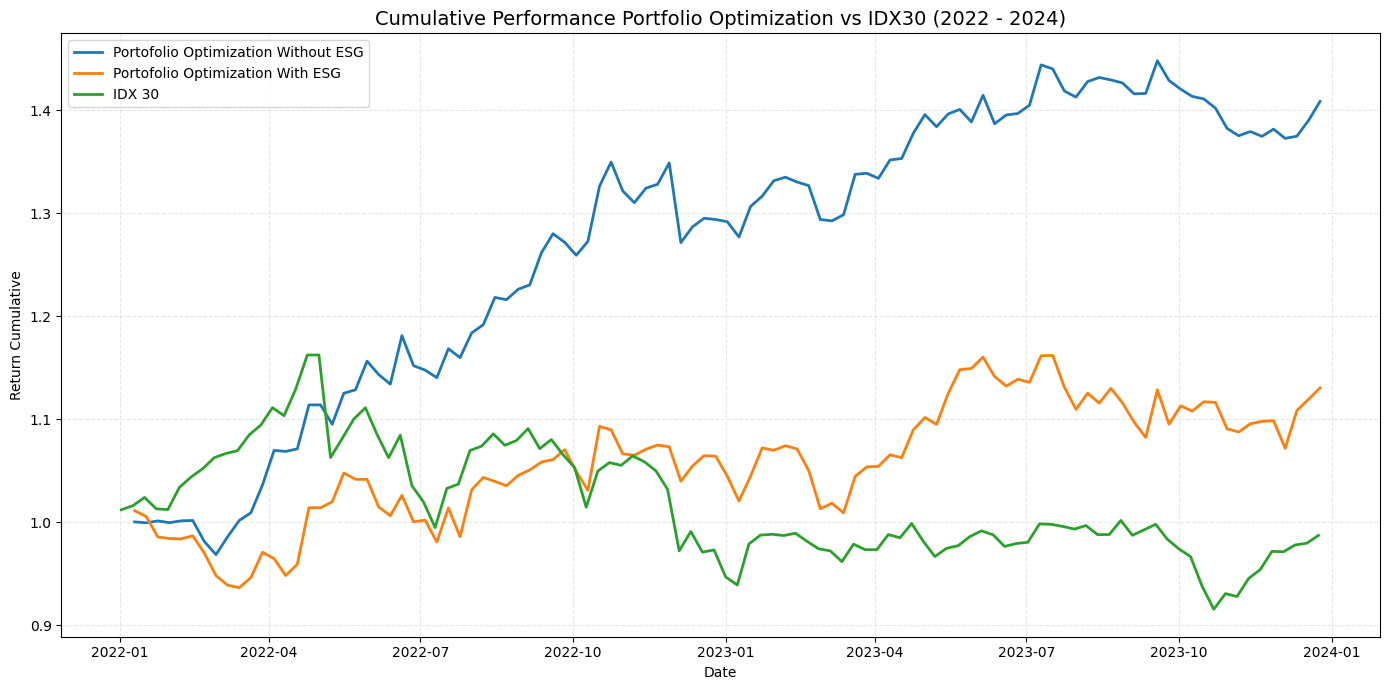

In [ ]:
# Bobot Portofolio Tanpa ESG
dataOptimal_float = list(map(float, dataOptimalWESG['weights']))
weightsWESG = dict(zip(dataTicker, dataOptimal_float))
tickersWESG = list(weightsWESG.keys())


start_date = '2022-01-01'
end_date = '2024-01-01'
# Mengubah string menjadi objek datetime
start_date_obj = datetime.strptime(start_date, '%Y-%m-%d')
end_date_obj = datetime.strptime(end_date, '%Y-%m-%d')

# Mengambil tahun dari objek datetime
tahun_start = start_date_obj.year
tahun_end = end_date_obj.year
# Unduh Data Saham
dataWESG = yf.download(tickers, start=start_date, end=end_date, interval='1wk')['Close']
dataWESG = dataWESG.dropna()
returnsWESG = dataWESG.pct_change().dropna()

# Hitung Return Portofolio
portfolio_weightsWESG = np.array([weightsWESG[t] for t in tickers])
returns_portfolioWESG = returnsWESG.dot(portfolio_weightsWESG)

portfolio_cumWESG = (1 + returns_portfolioWESG).cumprod()


summary = {
    'Expected Return (%)': [
        (returns_portfolioWESG.mean()*52) * 100,
        (returns_portfolio.mean()*52) * 100,
        (returnsIDX30.mean()*52) * 100,
    ],
    'Risk (%)': [
        returns_portfolioWESG.std() * np.sqrt(52) * 100,
        returns_portfolio.std() * np.sqrt(52) * 100,
        returnsIDX30.std() * np.sqrt(52) * 100,
    ],
    'Sharpe Ratio': [
        ((returns_portfolioWESG.mean() * 52) - 0.0665) / (returns_portfolioWESG.std() * np.sqrt(52)),
        ((returns_portfolio.mean() * 52) - 0.0665) / (returns_portfolio.std() * np.sqrt(52)),
        ((returnsIDX30.mean() * 52) - 0.0665) / (returnsIDX30.std() * np.sqrt(52)),
    ],
    'ESG Score': [
        np.dot(portfolio_weightsWESG, esg_df['ESG_Score'] ),
        np.dot(portfolio_weights, esg_df['ESG_Score'] ),
        np.mean(esg_df['ESG_Score']),
    ]
}

summary_dfWESG = pd.DataFrame(summary, index=[
    'Portofolio PSO Without ESG',
    'Portfolio PSO With ESG',
    'IDX 30'
])

# 6. Cetak Rangkuman
print("\n📊 Rangkuman Kinerja Portofolio vs ETF IDX30")
print("---------------------------------------------------")
print(summary_dfWESG.round(2))

# 7. Visualisasi
plt.figure(figsize=(14, 7))
plt.plot(portfolio_cumWESG, label='Portofolio Optimization Without ESG', linewidth=2)
plt.plot(portfolio_cum, label='Portofolio Optimization With ESG', linewidth=2)
plt.plot(idx30_cum, label='IDX 30', linewidth=2)

plt.title(f'Cumulative Performance Portfolio Optimization vs IDX30 ({tahun_start} - {tahun_end})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Return Cumulative')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
